In [ ]:
#importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc
import shap


In [ ]:
# Load the dataset from a CSV file into a pandas DataFrame for analysis
df = pd.read_csv("health_dataset.csv")

In [ ]:
# Loop through selected binary health condition columns
for col in [
    'has_diabetes',
    'has_hypertension',
    'has_heart_disease',
    'has_obesity',
    'has_stress_disorder'
]:
    print(col)  # Display the column name for reference

    # Show the proportion (normalized frequency) of each category (e.g., 0/1)
    print(df[col].value_counts(normalize=True))

    print()  # Add a blank line for better readability of output

has_diabetes
has_diabetes
0.0    0.657522
1.0    0.342478
Name: proportion, dtype: float64

has_hypertension
has_hypertension
1.0    0.54285
0.0    0.45715
Name: proportion, dtype: float64

has_heart_disease
has_heart_disease
0.0    0.695518
1.0    0.304482
Name: proportion, dtype: float64

has_obesity
has_obesity
0.0    0.770098
1.0    0.229902
Name: proportion, dtype: float64

has_stress_disorder
has_stress_disorder
0.0    0.66636
1.0    0.33364
Name: proportion, dtype: float64



In [ ]:
# Calculate the mean of each binary column, which represents the proportion (percentage) of individuals with each condition
df[['has_diabetes','has_hypertension','has_heart_disease','has_obesity','has_stress_disorder']].mean()

,0
has_diabetes,0.342478
has_hypertension,0.542850
has_heart_disease,0.304482
has_obesity,0.229902
has_stress_disorder,0.333640


In [ ]:
# Load a fresh copy of the dataset to preserve the original data before any preprocessing or modifications
df_original = pd.read_csv("health_dataset.csv")

In [ ]:
print(df_original.shape)# Output the number of rows and columns to understand the dataset's size and structure

# Display the first few rows to preview the data and inspect column values
df_original.head()

(105000, 32)


,age,gender,family_history,height,weight,bmi,sleep_hours,daily_steps,training_hours,screen_time,...,triglycerides,total_cholesterol,glucose,insulin,heart_rate,has_diabetes,has_hypertension,has_heart_disease,has_obesity,has_stress_disorder
0,56.0,male,yes,1.58,61.5,24.6,8.1,4274.0,1.61,6.1,...,216.0,200.0,110.0,16.1,86.0,0.0,0.0,1.0,0.0,0.0
1,69.0,male,no,1.61,95.7,36.9,7.7,7615.0,0.70,5.9,...,196.0,251.0,150.0,21.7,87.0,1.0,1.0,0.0,1.0,1.0
2,46.0,male,no,1.73,74.8,NaN,8.0,5640.0,0.96,7.2,...,182.0,218.0,131.0,19.1,74.0,0.0,0.0,0.0,0.0,0.0
3,32.0,male,no,1.76,80.0,25.8,8.0,4425.0,1.06,8.8,...,215.0,221.0,156.0,NaN,87.0,0.0,1.0,1.0,0.0,0.0
4,60.0,female,yes,1.82,81.0,24.5,6.8,7920.0,2.71,7.0,...,205.0,186.0,109.0,14.5,79.0,1.0,1.0,1.0,0.0,0.0


In [ ]:
df_original.tail() # Display the last few rows to check the end of the dataset and ensure data has loaded correctly

,age,gender,family_history,height,weight,bmi,sleep_hours,daily_steps,training_hours,screen_time,...,triglycerides,total_cholesterol,glucose,insulin,heart_rate,has_diabetes,has_hypertension,has_heart_disease,has_obesity,has_stress_disorder
104995,68.0,female,yes,1.81,42.5,13.0,8.4,9285.0,0.16,7.5,...,180.0,219.0,NaN,6.4,74.0,0.0,1.0,1.0,0.0,0.0
104996,42.0,male,no,1.60,60.5,23.6,5.3,4720.0,NaN,5.0,...,168.0,216.0,95.0,12.4,57.0,1.0,1.0,0.0,0.0,0.0
104997,53.0,male,yes,1.82,74.6,22.5,7.5,5432.0,6.00,6.0,...,154.0,221.0,120.0,18.0,56.0,0.0,0.0,1.0,0.0,1.0
104998,44.0,female,no,1.60,75.4,29.5,5.0,3828.0,0.01,1.0,...,NaN,169.0,121.0,15.5,76.0,1.0,1.0,0.0,0.0,0.0
104999,51.0,female,no,1.83,45.0,NaN,8.4,5174.0,1.63,3.4,...,230.0,201.0,153.0,10.0,73.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_original.info() # Display a summary of the DataFrame, including column names, data types, non-null counts, and memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105000 entries, 0 to 104999
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   age                  101566 non-null  float64
 1   gender               101473 non-null  object 
 2   family_history       100855 non-null  object 
 3   height               101751 non-null  float64
 4   weight               101819 non-null  float64
 5   bmi                  101554 non-null  float64
 6   sleep_hours          101394 non-null  float64
 7   daily_steps          103402 non-null  float64
 8   training_hours       101690 non-null  float64
 9   screen_time          102428 non-null  float64
 10  meals_per_day        101010 non-null  float64
 11  calorie_intake       99637 non-null   float64
 12  sugar_intake         103108 non-null  float64
 13  diet_type            101786 non-null  object 
 14  stress_level         99712 non-null   float64
 15  mental_health_sco

In [ ]:
df_original.describe().T  # Generate summary statistics for numerical columns and transpose for easier readability

,count,mean,std,min,25%,50%,75%,max
age,101566.0,48.529085,17.886493,18.00,33.000000,48.000000,64.00000,79.000000
height,101751.0,1.699765,0.099927,1.29,1.630000,1.700000,1.77000,2.140000
weight,101819.0,72.026928,16.083336,5.60,61.200000,72.000000,82.90000,139.600000
bmi,101554.0,25.189657,6.418782,2.00,20.800000,24.800000,29.20000,57.900000
sleep_hours,101394.0,6.982956,1.466674,3.00,6.000000,7.000000,8.00000,10.000000
daily_steps,103402.0,7028.270208,2945.286058,1000.00,4978.000000,7003.000000,9021.00000,20000.000000
training_hours,101690.0,1.473681,1.384364,0.00,0.430000,1.040000,2.09000,6.000000
screen_time,102428.0,5.007445,1.963650,1.00,3.600000,5.000000,6.30000,12.000000
meals_per_day,101010.0,3.499198,1.117339,2.00,3.000000,3.000000,5.00000,5.000000
calorie_intake,99637.0,2202.903199,488.807967,1200.00,1863.000000,2198.000000,2531.00000,4000.000000


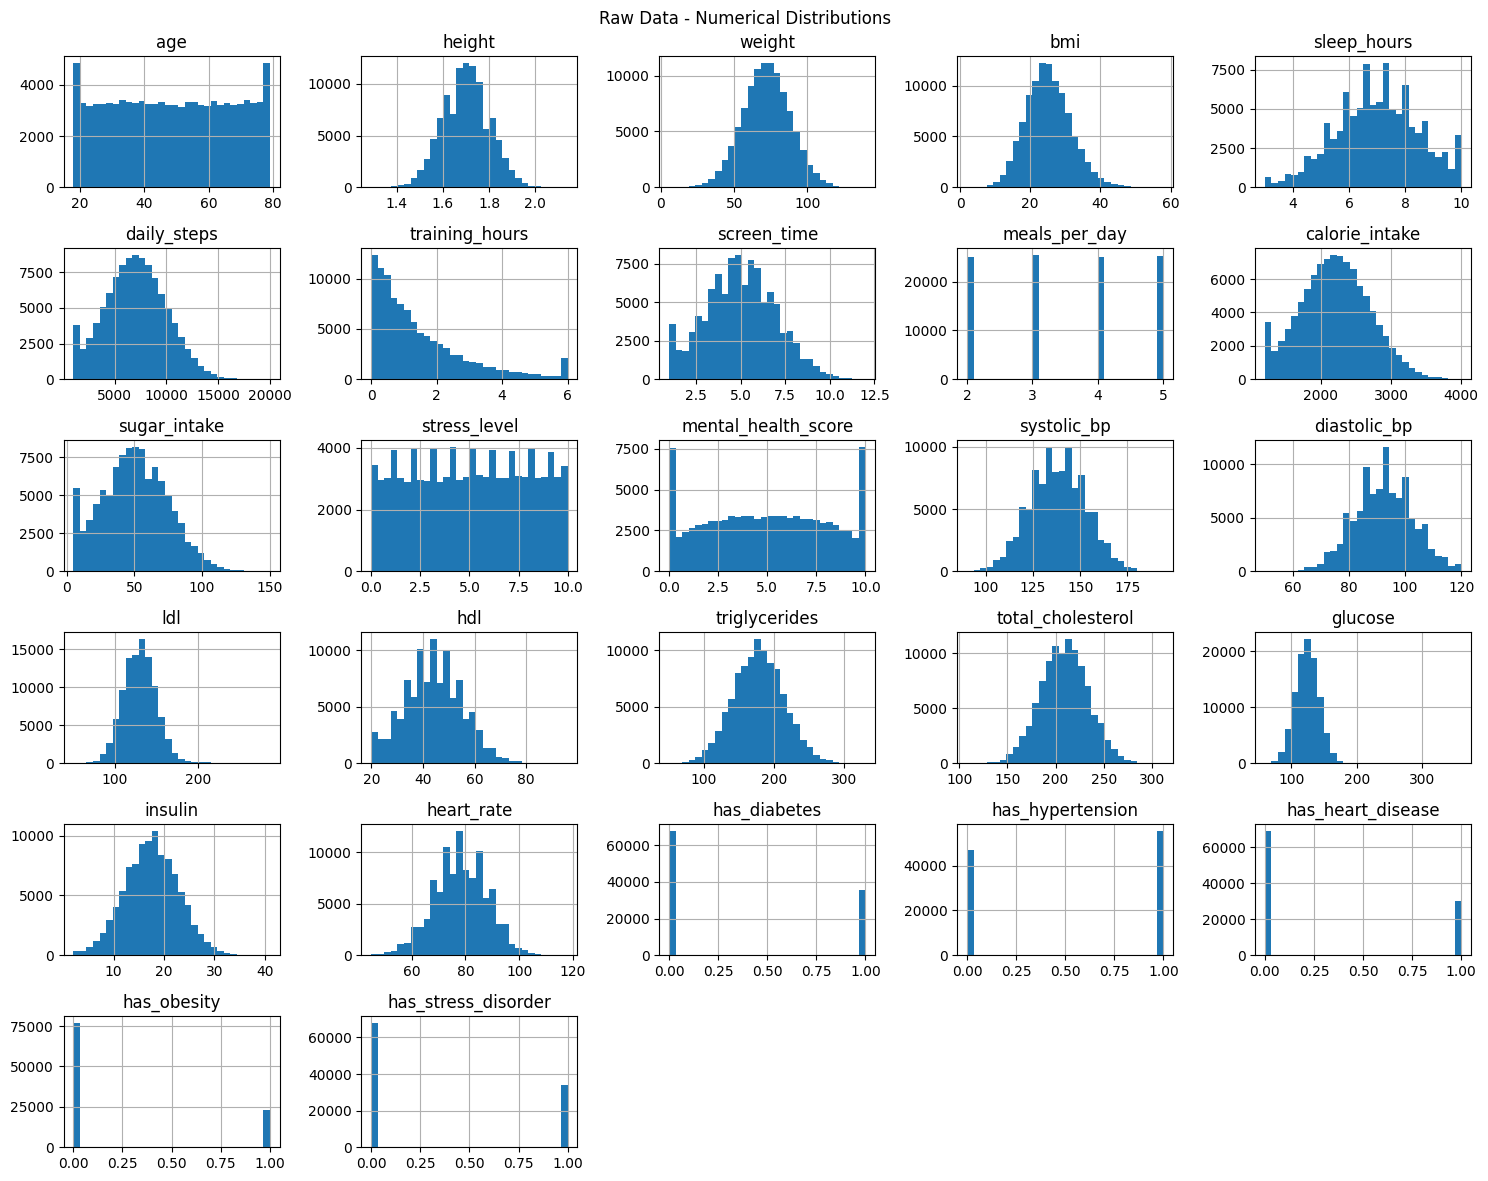

In [ ]:
# Plot histograms of numerical features to visualise their distributions
df_original.hist(figsize=(15, 12), bins=30)
plt.suptitle("Raw Data - Numerical Distributions")
plt.tight_layout()
plt.show()

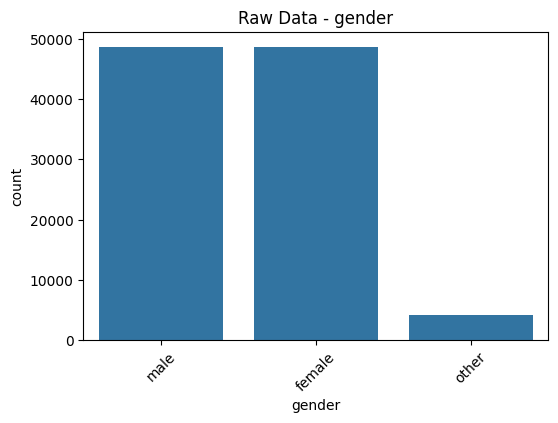

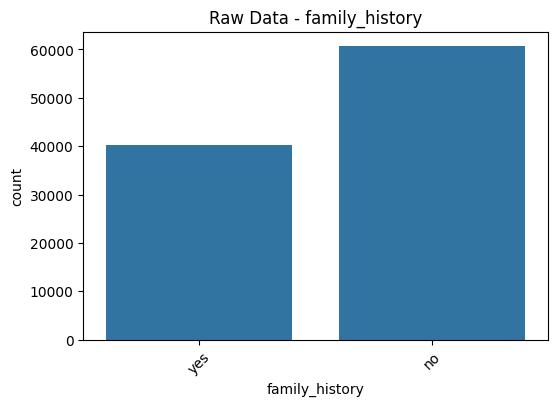

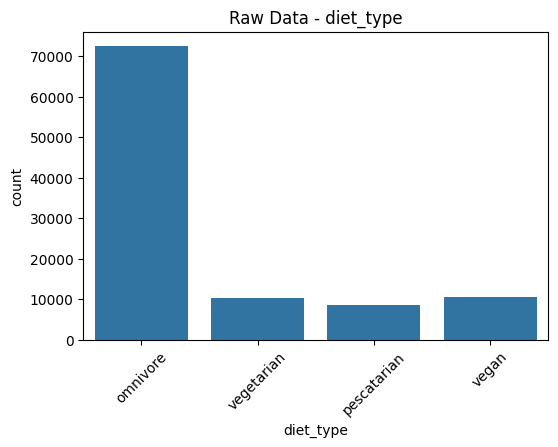

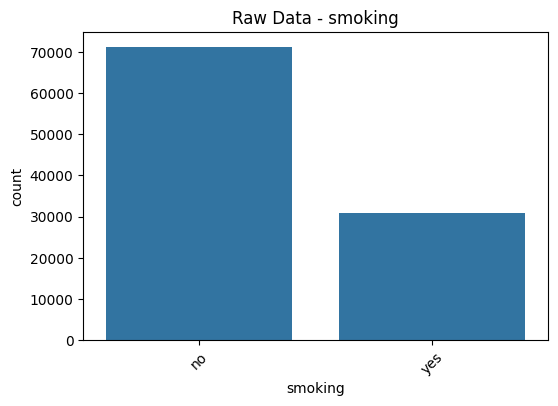

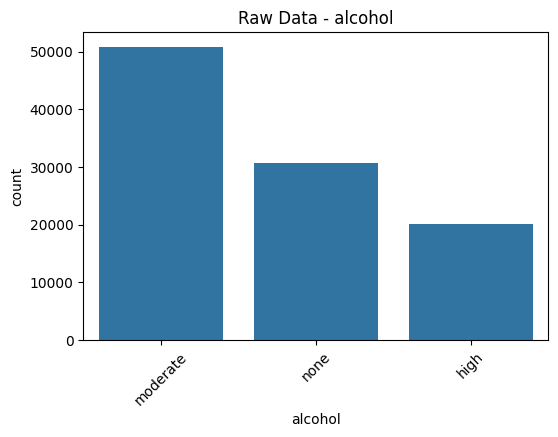

In [ ]:
# Plot count distributions for all categorical features to visualise category frequencies
cat_cols = df_original.select_dtypes(include=['object']).columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df_original[col])
    plt.title(f"Raw Data - {col}")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
df = df_original.copy() # Create a working copy of the dataset to avoid modifying the original data

In [ ]:
# Verify dataset structure, data types, and preview first rows after creating a working copy
print(df.shape)
print(df.info())
df.head()

(105000, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105000 entries, 0 to 104999
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   age                  101566 non-null  float64
 1   gender               101473 non-null  object 
 2   family_history       100855 non-null  object 
 3   height               101751 non-null  float64
 4   weight               101819 non-null  float64
 5   bmi                  101554 non-null  float64
 6   sleep_hours          101394 non-null  float64
 7   daily_steps          103402 non-null  float64
 8   training_hours       101690 non-null  float64
 9   screen_time          102428 non-null  float64
 10  meals_per_day        101010 non-null  float64
 11  calorie_intake       99637 non-null   float64
 12  sugar_intake         103108 non-null  float64
 13  diet_type            101786 non-null  object 
 14  stress_level         99712 non-null   float64
 15  ment

,age,gender,family_history,height,weight,bmi,sleep_hours,daily_steps,training_hours,screen_time,...,triglycerides,total_cholesterol,glucose,insulin,heart_rate,has_diabetes,has_hypertension,has_heart_disease,has_obesity,has_stress_disorder
0,56.0,male,yes,1.58,61.5,24.6,8.1,4274.0,1.61,6.1,...,216.0,200.0,110.0,16.1,86.0,0.0,0.0,1.0,0.0,0.0
1,69.0,male,no,1.61,95.7,36.9,7.7,7615.0,0.70,5.9,...,196.0,251.0,150.0,21.7,87.0,1.0,1.0,0.0,1.0,1.0
2,46.0,male,no,1.73,74.8,NaN,8.0,5640.0,0.96,7.2,...,182.0,218.0,131.0,19.1,74.0,0.0,0.0,0.0,0.0,0.0
3,32.0,male,no,1.76,80.0,25.8,8.0,4425.0,1.06,8.8,...,215.0,221.0,156.0,NaN,87.0,0.0,1.0,1.0,0.0,0.0
4,60.0,female,yes,1.82,81.0,24.5,6.8,7920.0,2.71,7.0,...,205.0,186.0,109.0,14.5,79.0,1.0,1.0,1.0,0.0,0.0


In [ ]:
# Display all column names to understand available features in the dataset
print("Columns:")
print(df.columns)

Columns:
Index(['age', 'gender', 'family_history', 'height', 'weight', 'bmi',
       'sleep_hours', 'daily_steps', 'training_hours', 'screen_time',
       'meals_per_day', 'calorie_intake', 'sugar_intake', 'diet_type',
       'stress_level', 'mental_health_score', 'smoking', 'alcohol',
       'systolic_bp', 'diastolic_bp', 'ldl', 'hdl', 'triglycerides',
       'total_cholesterol', 'glucose', 'insulin', 'heart_rate', 'has_diabetes',
       'has_hypertension', 'has_heart_disease', 'has_obesity',
       'has_stress_disorder'],
      dtype='object')


In [ ]:
print("Categorical describe:") #catgorical features analysed to understand class distribution

print(
    df.describe(
        include="object"
    )
)

Categorical describe:
        gender family_history diet_type smoking   alcohol
count   101473         100855    101786  102334    101683
unique       3              2         4       2         3
top       male             no  omnivore      no  moderate
freq     48758          60626     72407   71349     50856


check and handle missing values

In [ ]:
# Calculate and display missing values per column as counts and percentages, sorted by highest missingness
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percent': missing_percent
}).sort_values(by='Missing_Percent', ascending=False)

print(missing_df)

                     Missing_Count  Missing_Percent
mental_health_score           5514         5.251429
calorie_intake                5363         5.107619
has_heart_disease             5329         5.075238
stress_level                  5288         5.036190
triglycerides                 4829         4.599048
has_obesity                   4805         4.576190
ldl                           4532         4.316190
systolic_bp                   4394         4.184762
insulin                       4363         4.155238
family_history                4145         3.947619
meals_per_day                 3990         3.800000
sleep_hours                   3606         3.434286
gender                        3527         3.359048
bmi                           3446         3.281905
age                           3434         3.270476
alcohol                       3317         3.159048
training_hours                3310         3.152381
height                        3249         3.094286
diet_type   

In [ ]:
df.isnull().sum() # Display the total number of missing values in each column

,0
age,3434
gender,3527
family_history,4145
height,3249
weight,3181
bmi,3446
sleep_hours,3606
daily_steps,1598
training_hours,3310
screen_time,2572


In [ ]:
# Separate columns into numerical (int/float) and categorical (object) types for appropriate preprocessing
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [ ]:
# Replace missing values in numerical columns with the median of each column
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
# Impute missing values in categorical columns using the most common category (mode)
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum() # Check the dataset after imputation to confirm that missing values have been handled

,0
age,0
gender,0
family_history,0
height,0
weight,0
bmi,0
sleep_hours,0
daily_steps,0
training_hours,0
screen_time,0


Check duplicates

In [ ]:
# Count and display the number of duplicate rows in the dataset
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

Duplicate rows: 0


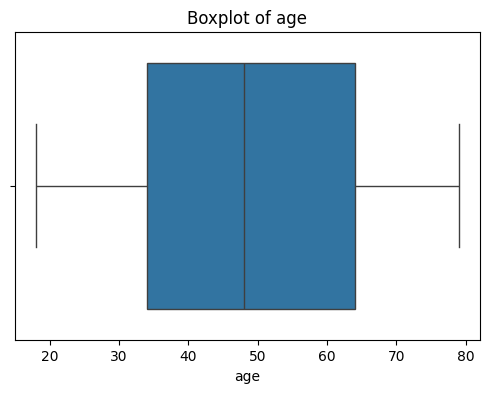

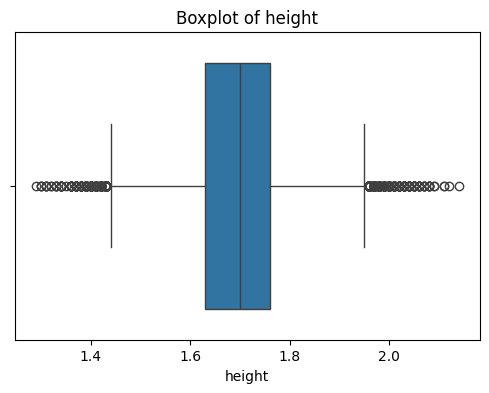

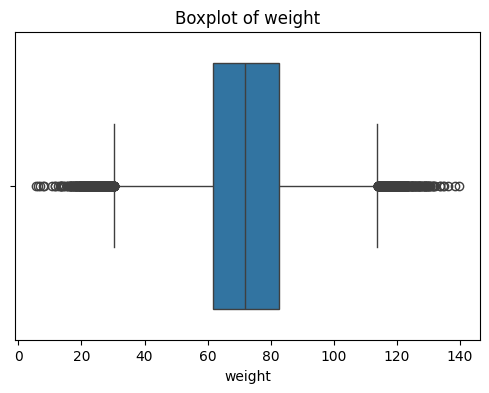

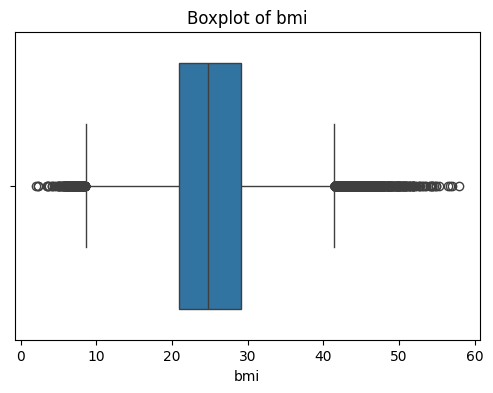

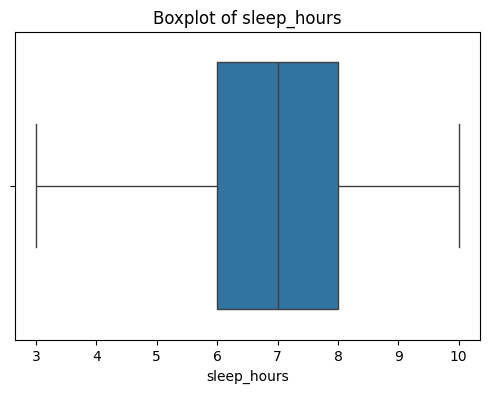

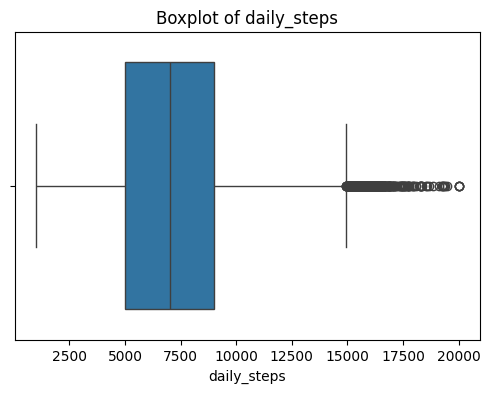

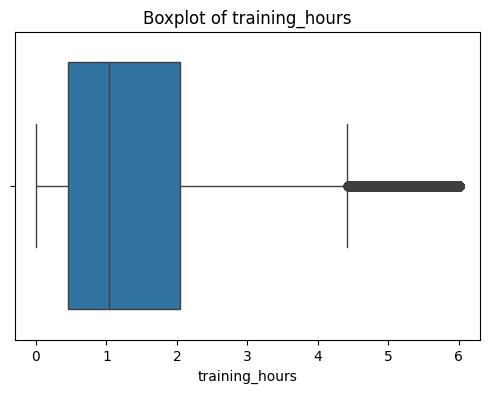

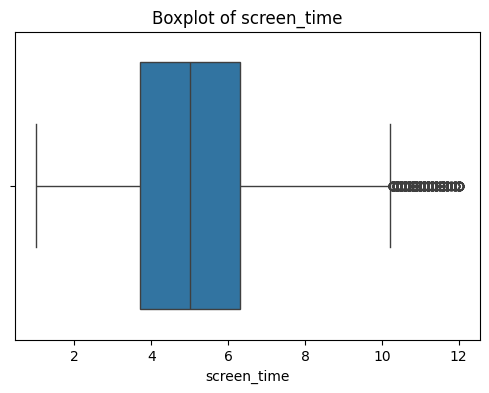

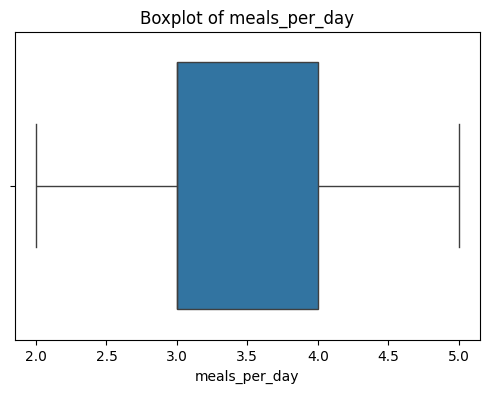

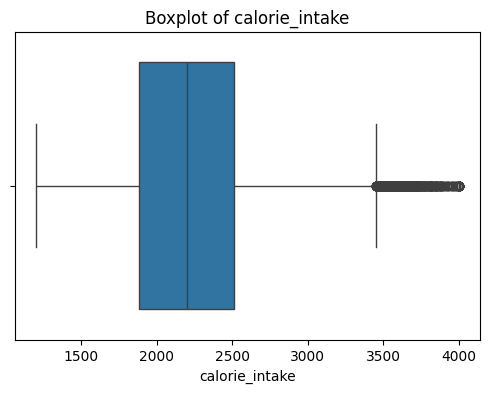

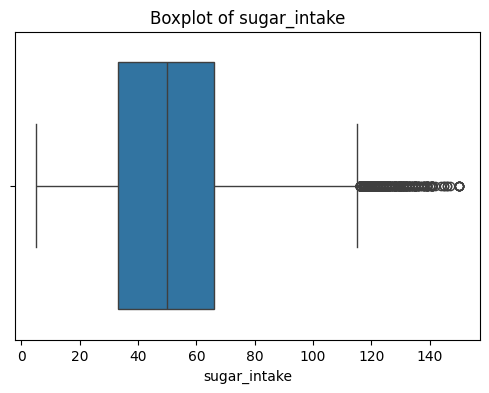

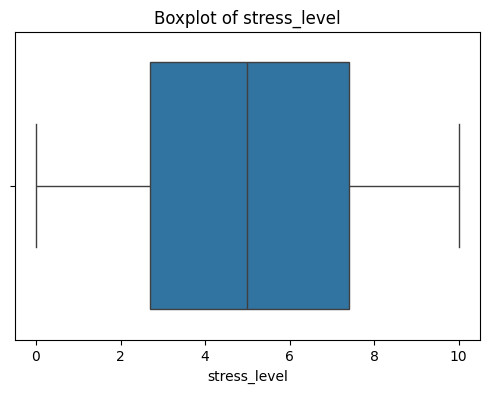

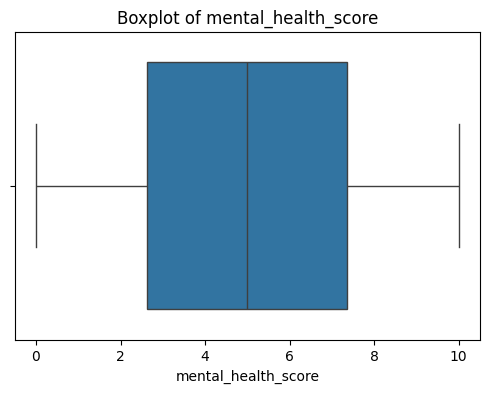

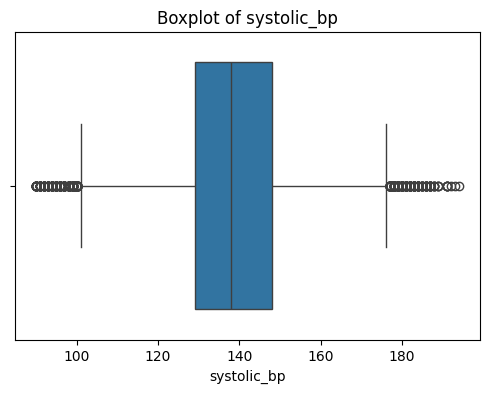

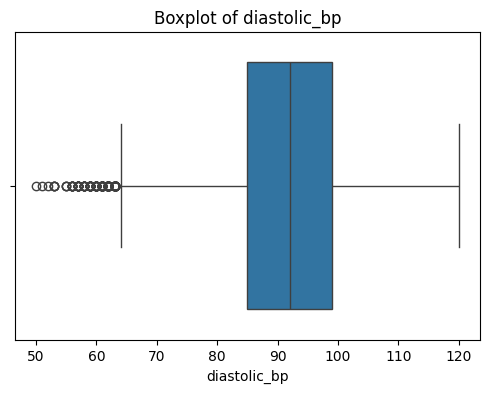

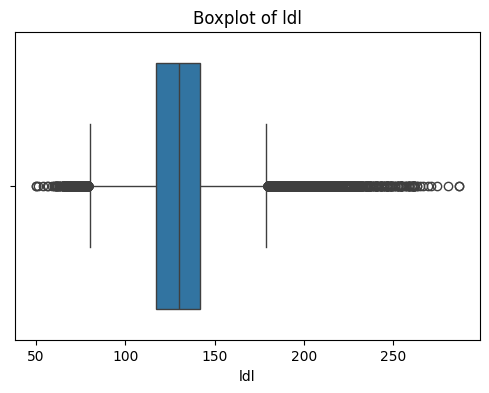

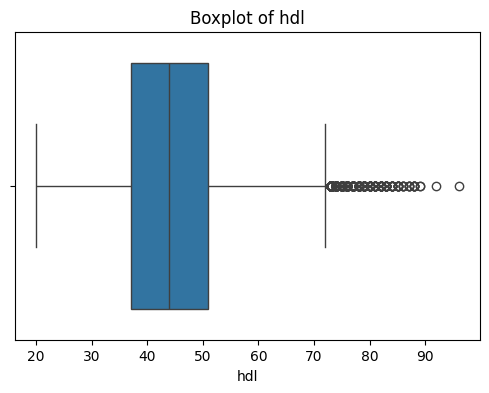

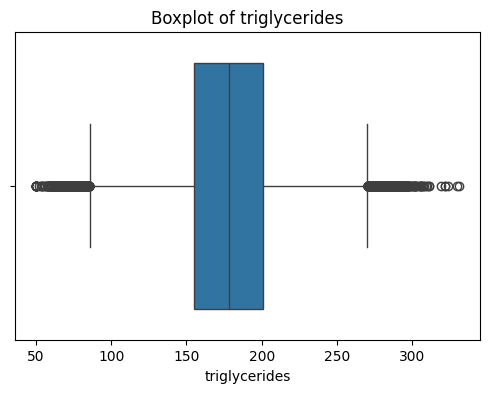

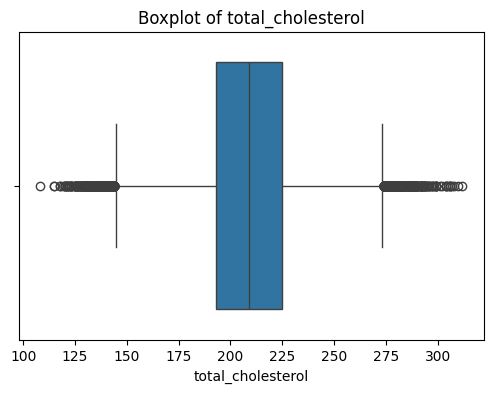

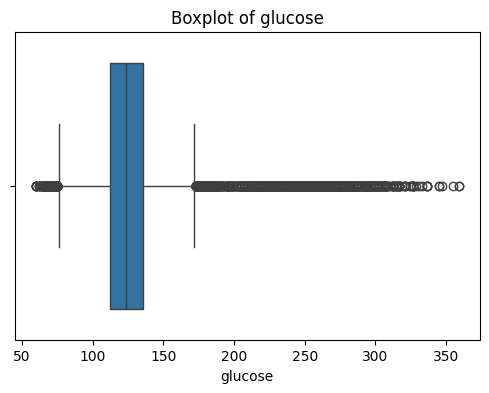

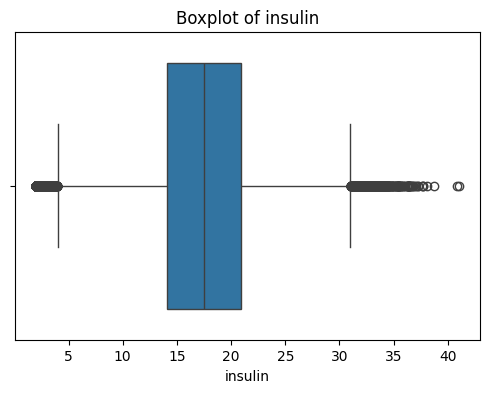

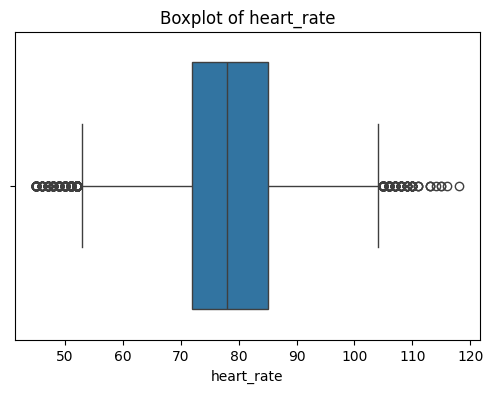

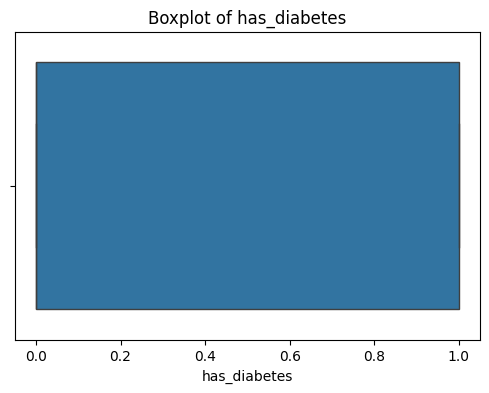

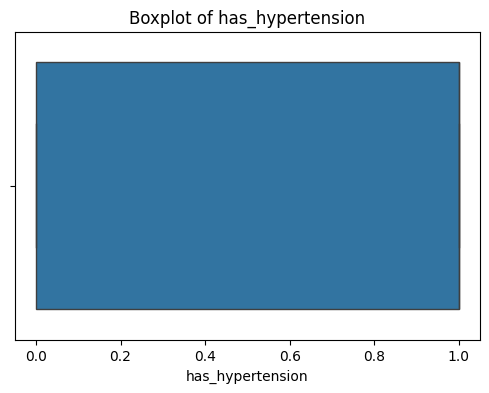

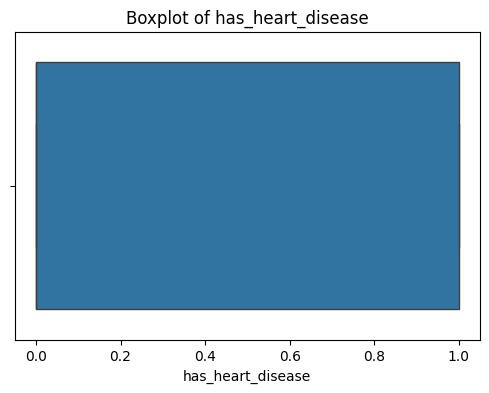

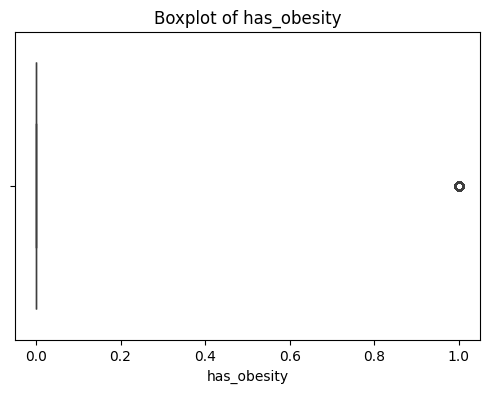

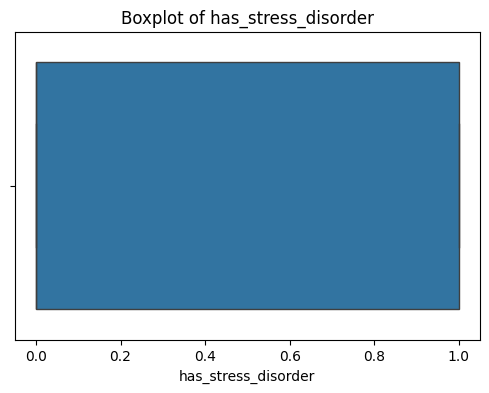

In [ ]:
# Visualise outliers in numerical features using boxplots
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create summary DataFrame
min_max_df = pd.DataFrame({
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max()
})

print(min_max_df)

                         Min           Max
age                    18.00     79.000000
height                  1.29      2.140000
weight                  5.60    139.600000
bmi                     2.00     57.900000
sleep_hours             3.00     10.000000
daily_steps          1000.00  20000.000000
training_hours          0.00      6.000000
screen_time             1.00     12.000000
meals_per_day           2.00      5.000000
calorie_intake       1200.00   4000.000000
sugar_intake            5.00    150.000000
stress_level            0.00     10.000000
mental_health_score     0.00     10.000000
systolic_bp            90.00    194.000000
diastolic_bp           50.00    120.000000
ldl                    50.00    286.810738
hdl                    20.00     96.000000
triglycerides          50.00    331.000000
total_cholesterol     108.00    312.000000
glucose                60.00    358.959330
insulin                 2.00     41.000000
heart_rate             45.00    118.000000
has_diabete

In [ ]:
# Perform a domain sanity check by identifying values outside realistic medical/physiological ranges

sanity_rules = {
    "height": (1.2, 2.2),
    "weight": (33, 200),
    "bmi": (10, 60),

    "systolic_bp": (70, 250),
    "diastolic_bp": (40, 150),

    "glucose": (40, 400),
    "ldl": (0, 300),
    "hdl": (0, 150),
    "triglycerides": (0, 1000),
    "total_cholesterol": (100, 400),

    "heart_rate": (30, 220),
    "insulin": (0, 300),

    "calorie_intake": (800, 7000),
    "sugar_intake": (0, 500),

    "sleep_hours": (0, 24),
    "daily_steps": (0, 100000),
    "training_hours": (0, 24),
    "screen_time": (0, 24),

    "stress_level": (0, 10),
    "mental_health_score": (0, 10),
    "meals_per_day": (1, 10)
}

sanity_report = {}

for col, (low, high) in sanity_rules.items():
    if col in df.columns:
        invalid_count = ((df[col] < low) | (df[col] > high)).sum()
        sanity_report[col] = invalid_count
        print(f"{col}: {invalid_count} invalid values")

height: 0 invalid values
weight: 758 invalid values
bmi: 429 invalid values
systolic_bp: 0 invalid values
diastolic_bp: 0 invalid values
glucose: 0 invalid values
ldl: 0 invalid values
hdl: 0 invalid values
triglycerides: 0 invalid values
total_cholesterol: 0 invalid values
heart_rate: 0 invalid values
insulin: 0 invalid values
calorie_intake: 0 invalid values
sugar_intake: 0 invalid values
sleep_hours: 0 invalid values
daily_steps: 0 invalid values
training_hours: 0 invalid values
screen_time: 0 invalid values
stress_level: 0 invalid values
mental_health_score: 0 invalid values
meals_per_day: 0 invalid values


In [ ]:
# convert invalid values to NaN
for col, (low, high) in sanity_rules.items():
    if col in df.columns:
        df.loc[(df[col] < low) | (df[col] > high), col] = np.nan

In [ ]:
# Cap extreme outlier values within medically reasonable bounds to reduce the effect of noise/outliers
clip_limits = {
    'bmi': (15, 50),
    'systolic_bp': (90, 200),
    'diastolic_bp': (50, 120),
    'glucose': (60, 300),
    'ldl': (50, 250),
    'hdl': (20, 100),
    'triglycerides': (50, 500),
    'heart_rate': (40, 150),
    'insulin': (2, 50)
}

for col, (low, high) in clip_limits.items():
    if col in df.columns:
        df[col] = df[col].clip(low, high)

In [ ]:
# Impute missing values: numerical columns with median and categorical columns with mode after preprocessing
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

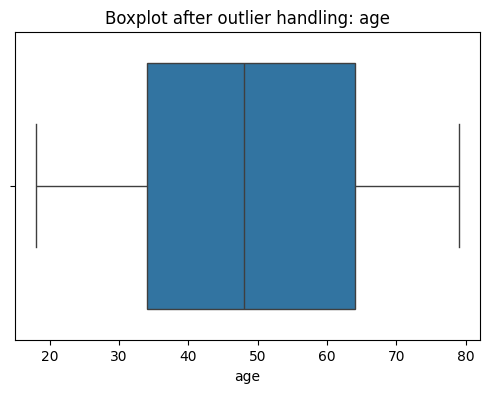

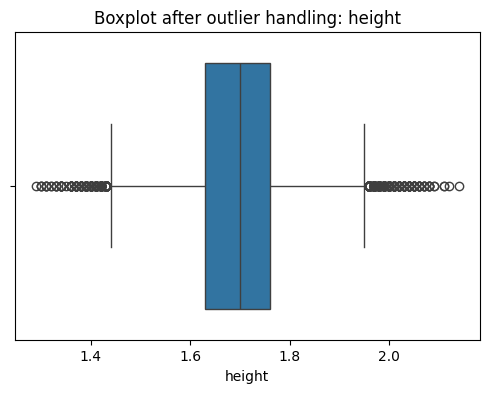

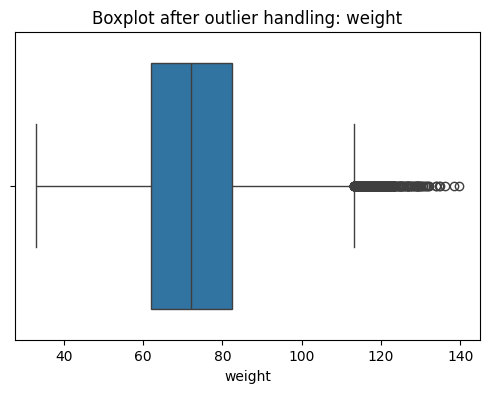

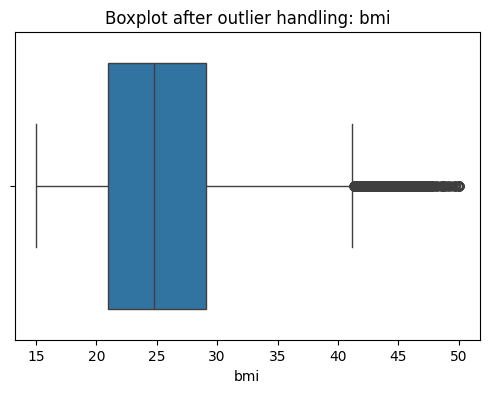

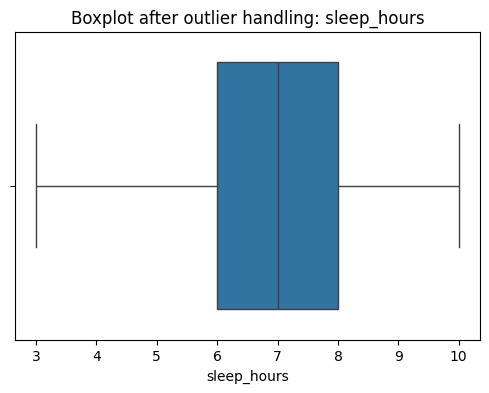

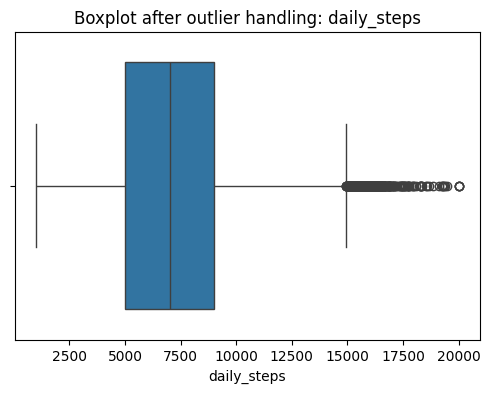

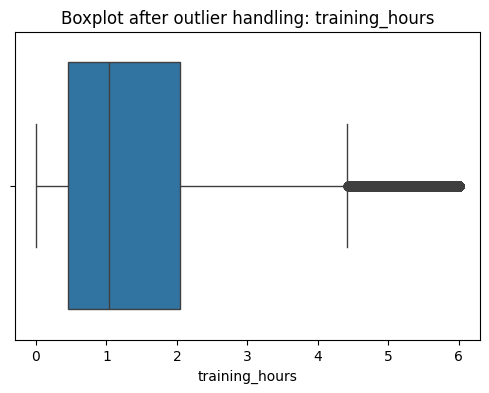

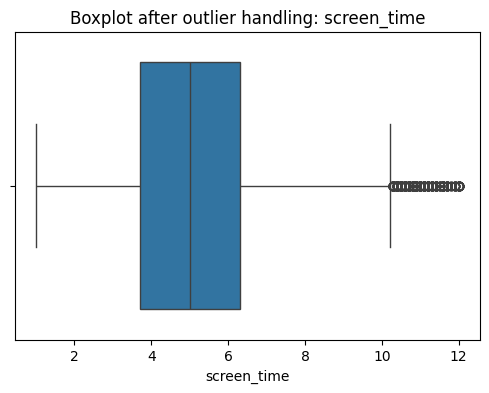

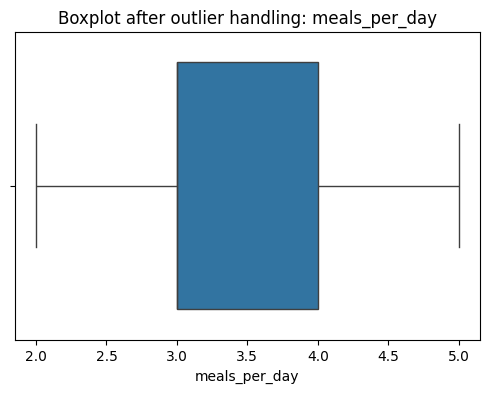

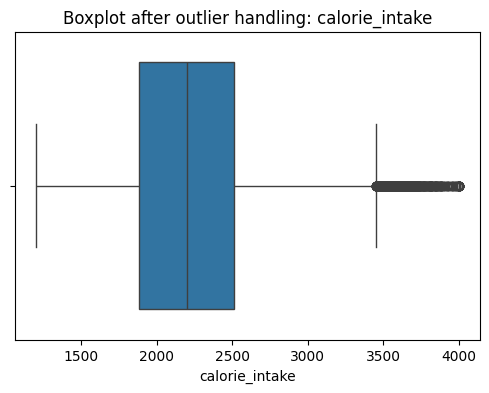

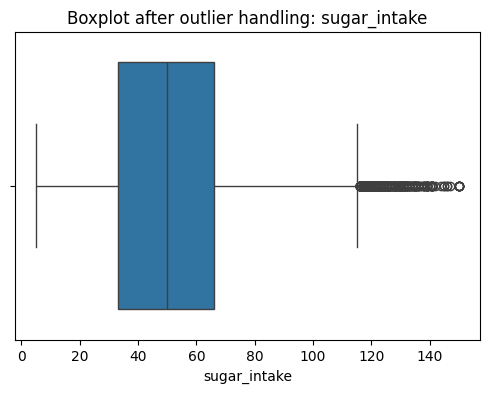

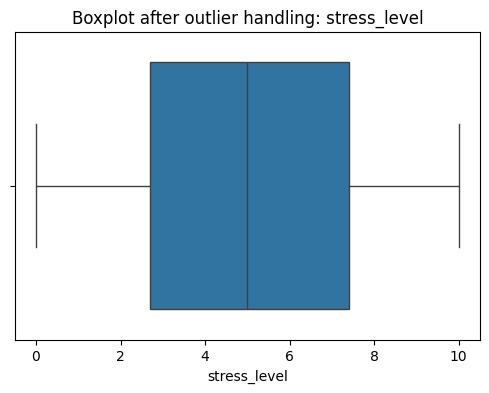

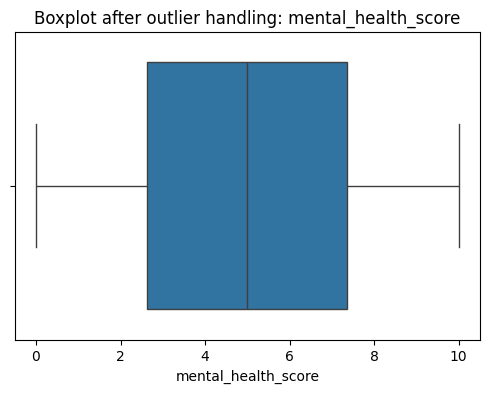

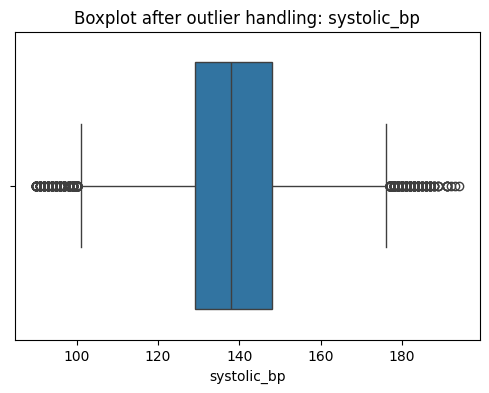

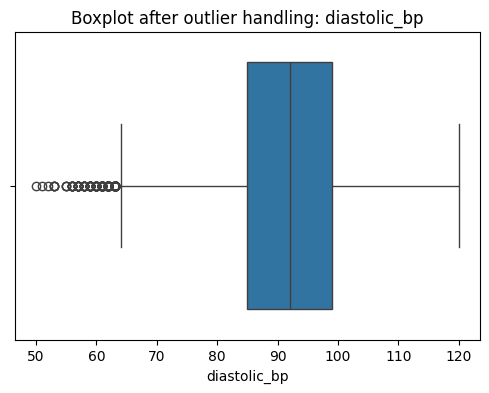

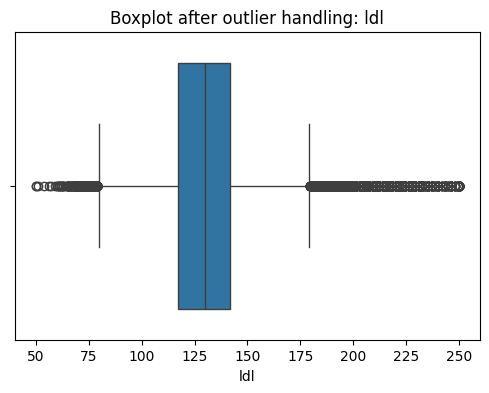

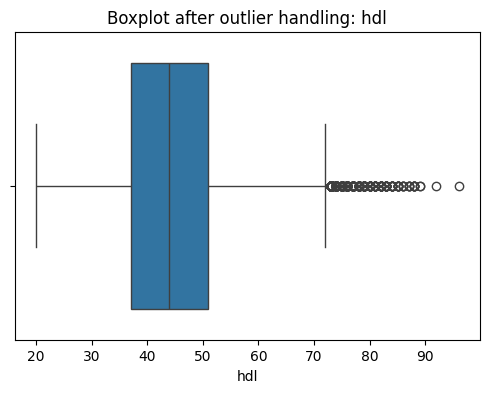

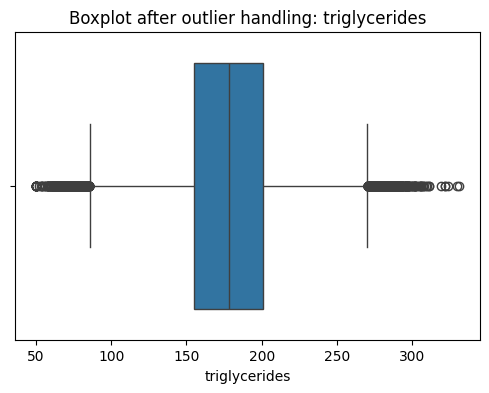

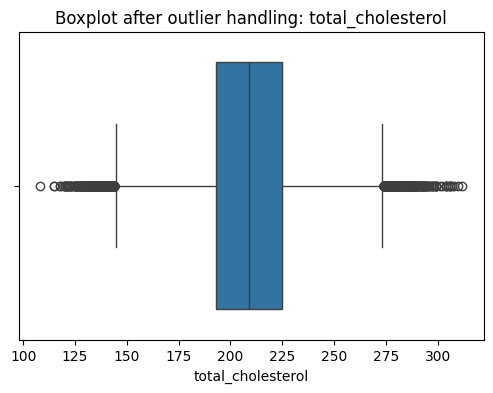

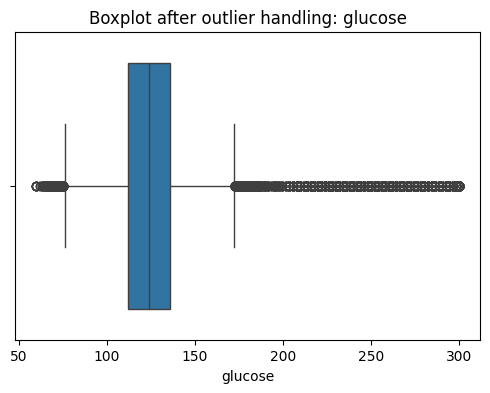

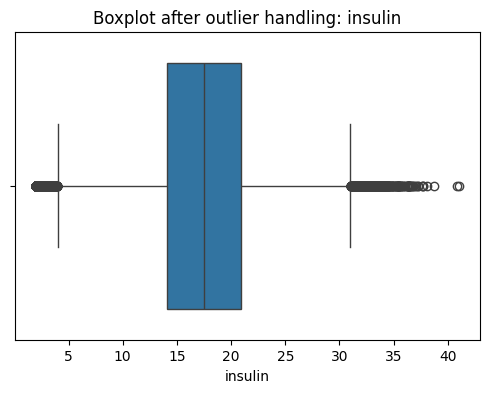

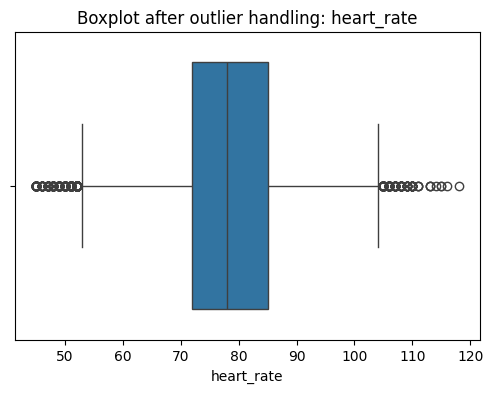

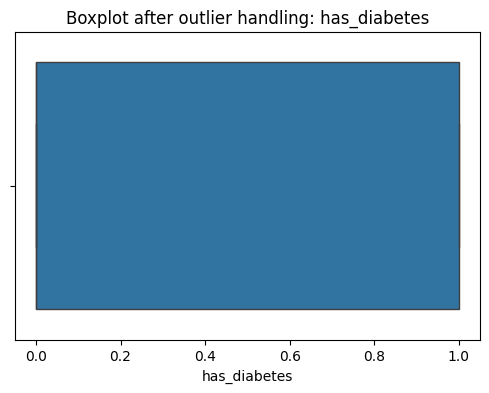

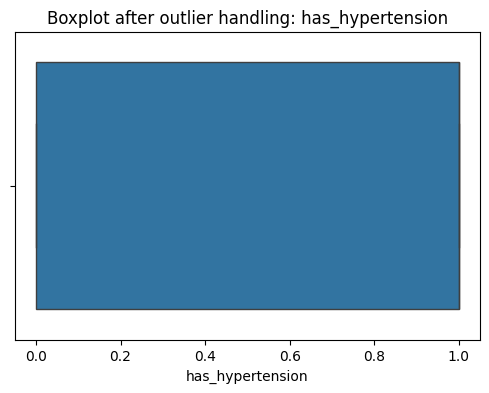

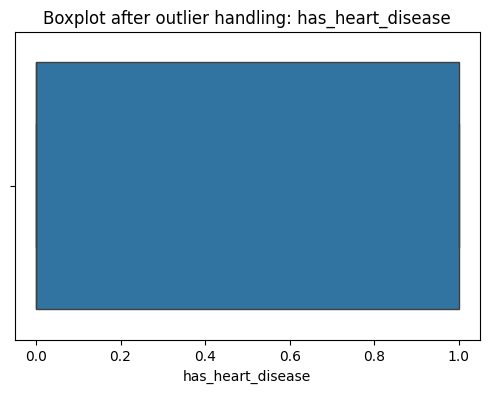

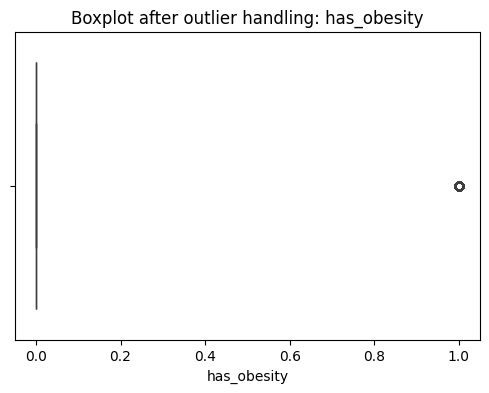

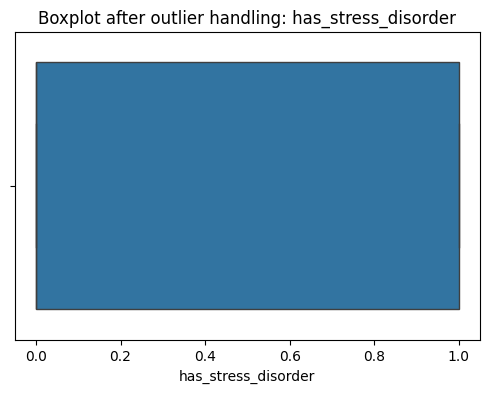

In [ ]:
# Select numerical columns and visualise boxplots to check data distribution after outlier handling
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot after outlier handling: {col}")
    plt.show()

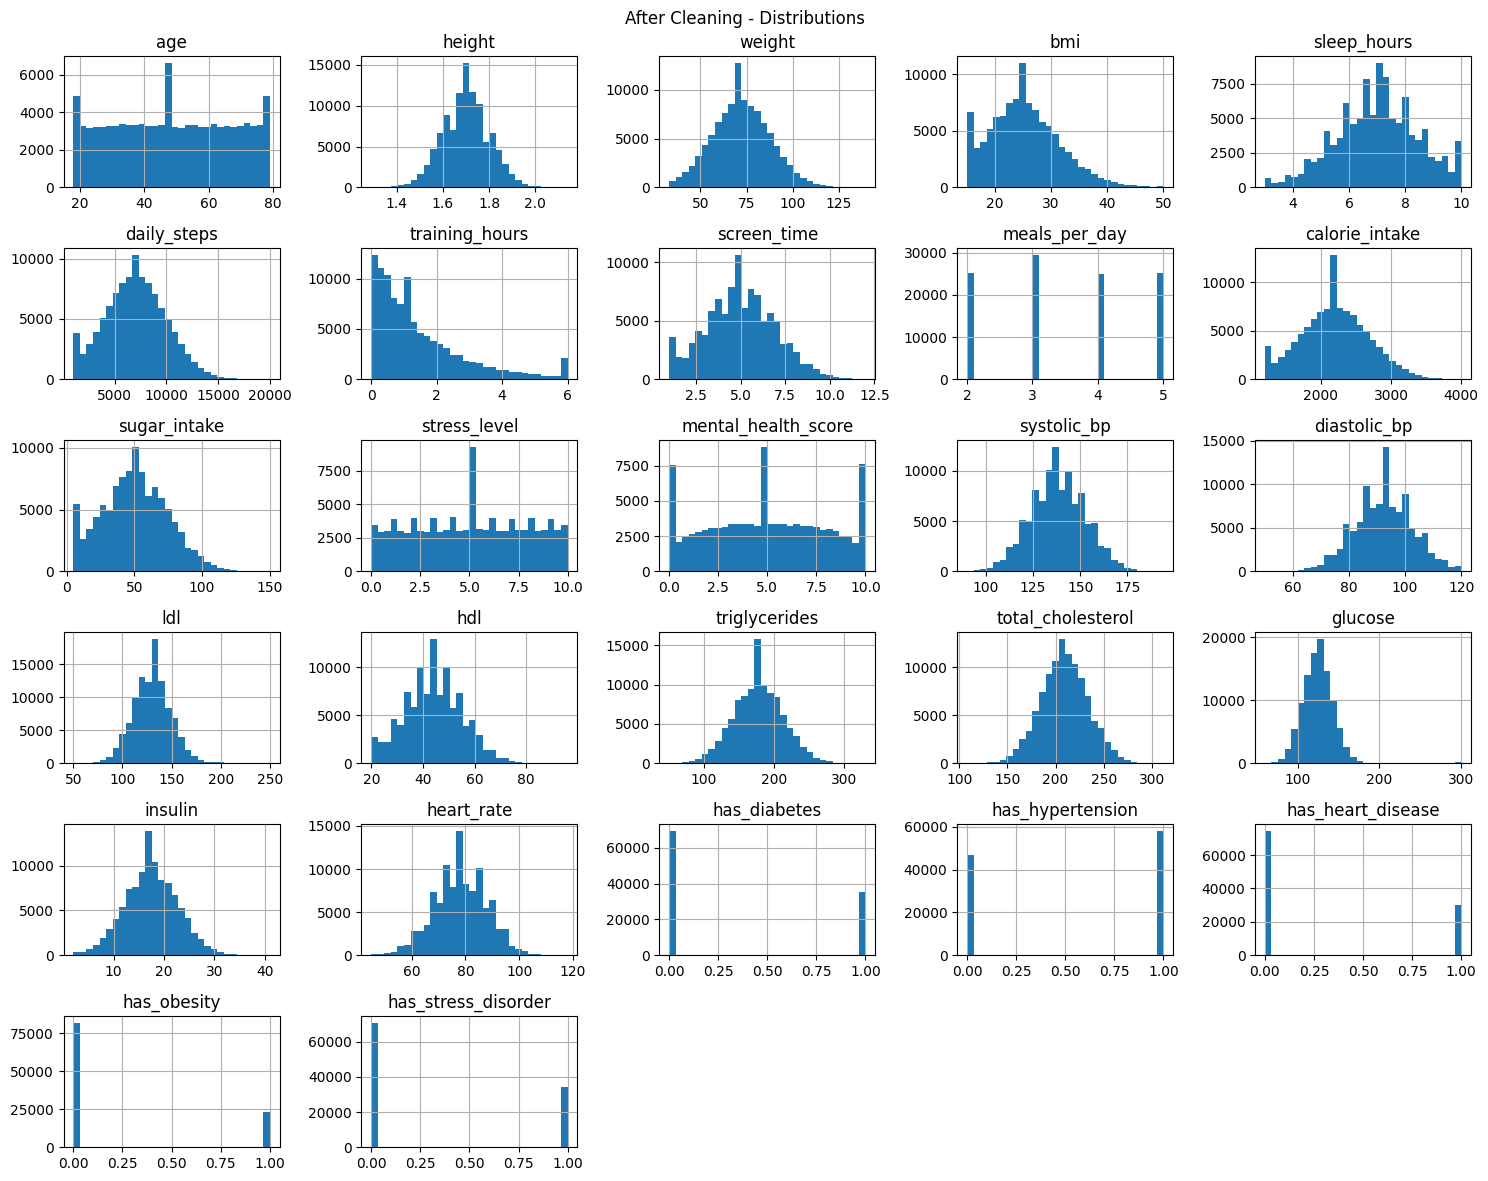

In [ ]:
# Plot histograms of all numerical features to visualise distributions after data cleaning
df.hist(figsize=(15, 12), bins=30)
plt.suptitle("After Cleaning - Distributions")
plt.tight_layout()
plt.show()

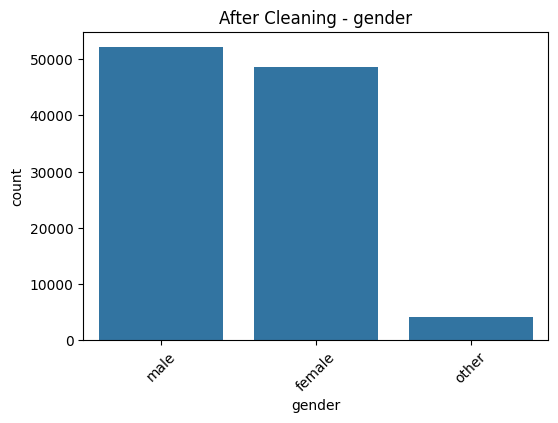

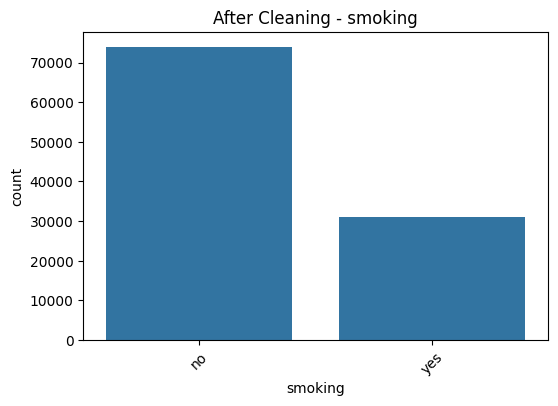

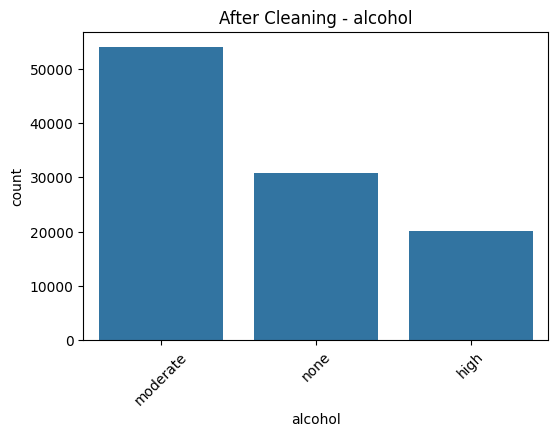

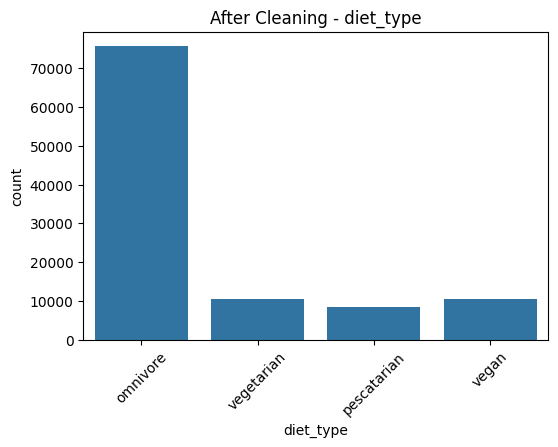

In [ ]:
# Visualise frequency distribution of categorical variables after data cleaning
cat_cols = ['gender', 'smoking', 'alcohol', 'diet_type', 'age_group']

for col in cat_cols:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.countplot(x=df[col])
        plt.title(f"After Cleaning - {col}")
        plt.xticks(rotation=45)
        plt.show()

Feature Engineering

In [ ]:
# Create BMI categories based on standard medical thresholds (underweight, normal, overweight, obese)
def bmi_category(bmi):
    if bmi < 18.5:
        return "underweight"
    elif bmi < 25:
        return "normal"
    elif bmi < 30:
        return "overweight"
    else:
        return "obese"

# Apply function to create a new categorical feature
df['bmi_category'] = df['bmi'].apply(bmi_category)

In [ ]:
# Categorise blood pressure into risk levels based on clinical thresholds
def bp_category(sys_bp):
    if sys_bp < 90:
        return "low"
    elif sys_bp < 120:
        return "normal"
    elif sys_bp < 140:
        return "elevated"
    elif sys_bp < 180:
        return "high"
    else:
        return "critical"

# Apply function to create a new feature representing blood pressure risk category
df['bp_category'] = df['systolic_bp'].apply(bp_category)

In [ ]:
# Calculate pulse pressure as the difference between systolic and diastolic blood pressure
df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']

In [ ]:
# Calculate Mean Arterial Pressure (MAP), a weighted average of systolic and diastolic blood pressure
df['map'] = (df['systolic_bp'] + 2 * df['diastolic_bp']) / 3

In [ ]:
# Classify glucose levels into clinical risk categories (low, normal, pre-diabetic, diabetic)
def glucose_category(g):
    if g < 70:
        return "low"
    elif g < 140:
        return "normal"
    elif g < 200:
        return "pre_diabetic"
    else:
        return "diabetic"

# Apply the function to create a new categorical feature for glucose risk
df['glucose_category'] = df['glucose'].apply(glucose_category)

In [ ]:
# Calculate LDL/HDL ratio as an indicator of cardiovascular risk, adding a small constant to avoid division by zero
df['ldl_hdl_ratio'] = df['ldl'] / (df['hdl'] + 1e-5)

In [ ]:
# Create a combined lipid burden score by summing key cholesterol-related measures
df['lipid_score'] = df['ldl'] + df['triglycerides'] + df['total_cholesterol']

In [ ]:
# Create a composite lifestyle score combining physical activity and dietary/screen-time factors
# Higher steps and training increase score, while higher screen time and sugar intake reduce it
df['lifestyle_score'] = (
    df['daily_steps'] +
    (df['training_hours'] * 1000) -
    df['screen_time'] * 500 -
    df['sugar_intake']
)

In [ ]:
# Create a sleep balance score where optimal sleep duration (7–9 hours) is marked as 1, otherwise 0
df['sleep_balance'] = df['sleep_hours'].apply(
    lambda x: 1 if 7 <= x <= 9 else 0
)

In [ ]:
# Create a composite metabolic risk index using weighted contributions from key health indicators
df['metabolic_risk'] = (
    df['bmi'] * 0.3 +
    df['glucose'] * 0.3 +
    df['ldl'] * 0.2 +
    df['triglycerides'] * 0.2
)

In [ ]:
# Categorise individuals into age groups to simplify demographic analysis
def age_group(age):
    if age < 30:
        return "young"
    elif age < 50:
        return "adult"
    elif age < 65:
        return "middle_aged"
    else:
        return "senior"

# Apply function to create a new categorical feature for age group
df['age_group'] = df['age'].apply(age_group)

Interaction features - to capture combined health risks between related variables

In [ ]:
# Glucose–insulin ratio as an indicator of insulin resistance
df['glucose_insulin_ratio'] = df['glucose'] / (df['insulin'] + 1e-5)

In [ ]:
# BMI–age interaction to represent long-term metabolic risk
df['bmi_age_risk'] = df['bmi'] * df['age']

In [ ]:
# Blood pressure–stress interaction to reflect cardiovascular stress load
df['bp_stress_index'] = df['systolic_bp'] * df['stress_level']

In [ ]:
# Cholesterol burden ratio combining LDL and triglycerides relative to HDL
df['cholesterol_burden'] = (
    df['ldl'] + df['triglycerides']
) / (df['hdl'] + 1e-5)

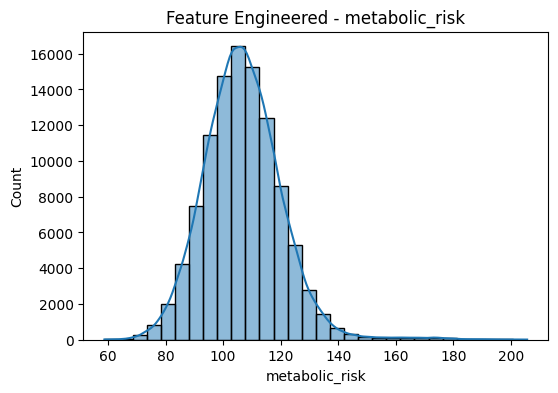

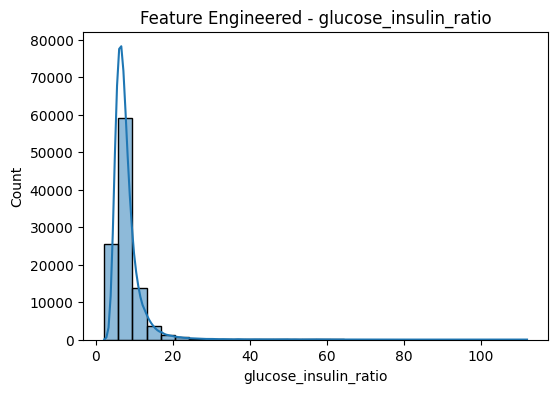

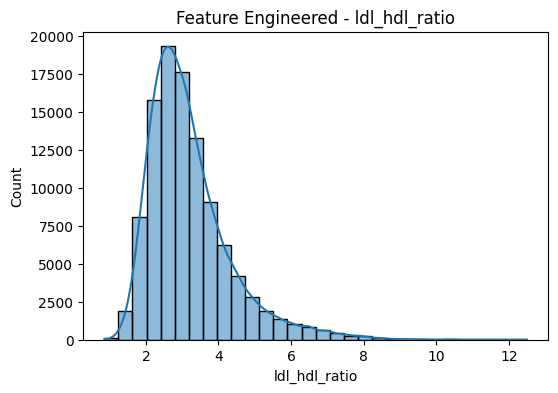

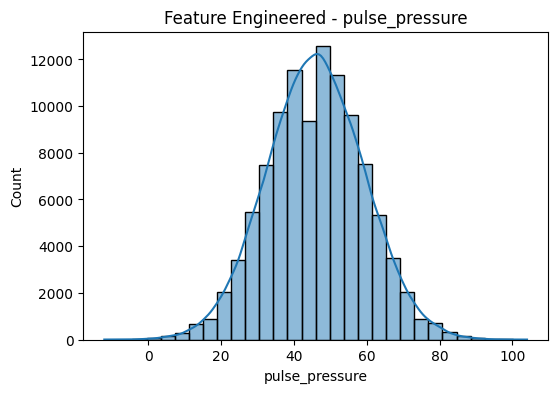

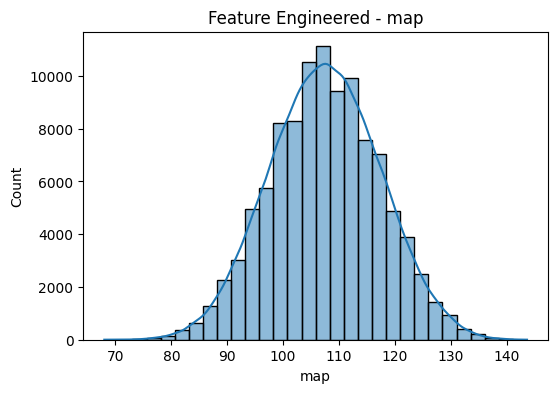

In [ ]:
# Visualise distributions of engineered features to understand their spread and shape
engineered_cols = [
    'composite_risk_score',
    'metabolic_risk',
    'glucose_insulin_ratio',
    'ldl_hdl_ratio',
    'pulse_pressure',
    'map'
]

for col in engineered_cols:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.histplot(df[col], bins=30, kde=True)
        plt.title(f"Feature Engineered - {col}")
        plt.show()

In [ ]:
# Visualise distribution of risk categories if the column exists
if 'risk_category' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df['risk_category'])
    plt.title("Risk Category Distribution")
    plt.show()

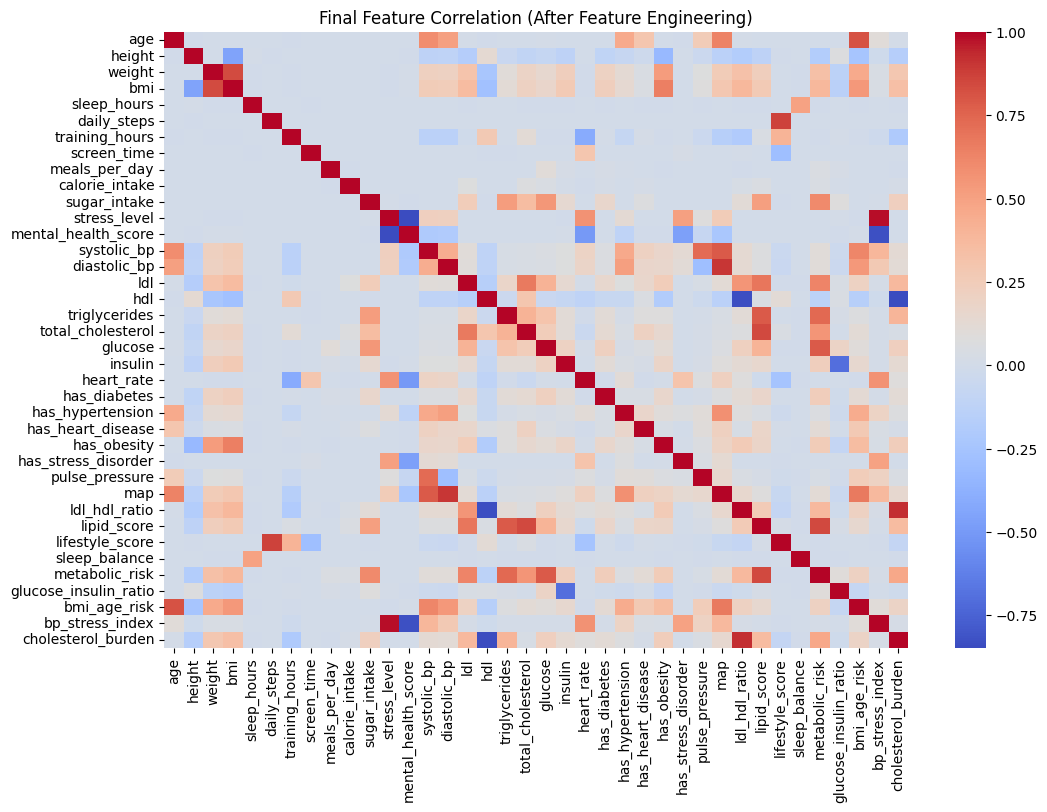

In [ ]:
# Plot correlation heatmap of all numerical features after feature engineering
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Final Feature Correlation (After Feature Engineering)")
plt.show()

In [ ]:
# Compute correlation matrix for numerical features
corr = df.corr(numeric_only=True)

# Display correlations with key health conditions to identify important relationships
print(corr['has_diabetes'].sort_values(ascending=False))
print(corr['has_obesity'].sort_values(ascending=False))

has_diabetes             1.000000
metabolic_risk           0.239610
bmi                      0.231136
glucose                  0.219296
weight                   0.199632
lipid_score              0.164558
has_obesity              0.158119
sugar_intake             0.157877
ldl                      0.155596
total_cholesterol        0.132462
bmi_age_risk             0.124035
cholesterol_burden       0.119620
ldl_hdl_ratio            0.118674
triglycerides            0.109761
insulin                  0.109012
map                      0.066185
diastolic_bp             0.057533
systolic_bp              0.055159
has_hypertension         0.039643
has_heart_disease        0.037741
meals_per_day            0.024045
pulse_pressure           0.015007
calorie_intake           0.015000
bp_stress_index          0.007496
training_hours           0.006518
mental_health_score      0.004199
screen_time              0.003738
has_stress_disorder      0.001222
age                     -0.000377
lifestyle_scor

In [ ]:
# Show top correlated features for other health outcomes
print(corr['has_hypertension'].sort_values(ascending=False).head(10))
print(corr['has_heart_disease'].sort_values(ascending=False).head(10))
print(corr['has_stress_disorder'].sort_values(ascending=False).head(10))

has_hypertension     1.000000
map                  0.574390
diastolic_bp         0.512654
systolic_bp          0.459627
age                  0.457544
bmi_age_risk         0.446836
bp_stress_index      0.197243
has_heart_disease    0.163921
bmi                  0.140307
stress_level         0.124707
Name: has_hypertension, dtype: float64
has_heart_disease    1.000000
age                  0.299180
bmi_age_risk         0.275202
map                  0.216102
systolic_bp          0.209860
total_cholesterol    0.207008
lipid_score          0.177056
diastolic_bp         0.167026
has_hypertension     0.163921
ldl                  0.156554
Name: has_heart_disease, dtype: float64
has_stress_disorder    1.000000
stress_level           0.504393
bp_stress_index        0.497945
heart_rate             0.310680
map                    0.134011
systolic_bp            0.121258
diastolic_bp           0.109793
has_hypertension       0.065255
pulse_pressure         0.045713
screen_time            0.024647
N

In [ ]:
# Remove redundant or highly correlated features to reduce multicollinearity and simplify the dataset

df = df.drop(columns=[
    'weight',
    'height',
    # 'systolic_bp',
    # 'diastolic_bp',
    'total_cholesterol',
    'lipid_score',
    'cholesterol_burden',
    'sleep_balance',
    'lifestyle_score'
], errors='ignore')

In [ ]:
print(df.shape)  # Check updated dataset shape and remaining features after feature removal
print(df.columns)

(105000, 40)
Index(['age', 'gender', 'family_history', 'bmi', 'sleep_hours', 'daily_steps',
       'training_hours', 'screen_time', 'meals_per_day', 'calorie_intake',
       'sugar_intake', 'diet_type', 'stress_level', 'mental_health_score',
       'smoking', 'alcohol', 'systolic_bp', 'diastolic_bp', 'ldl', 'hdl',
       'triglycerides', 'glucose', 'insulin', 'heart_rate', 'has_diabetes',
       'has_hypertension', 'has_heart_disease', 'has_obesity',
       'has_stress_disorder', 'bmi_category', 'bp_category', 'pulse_pressure',
       'map', 'glucose_category', 'ldl_hdl_ratio', 'metabolic_risk',
       'age_group', 'glucose_insulin_ratio', 'bmi_age_risk',
       'bp_stress_index'],
      dtype='object')


In [ ]:
# Split dataset into input features (X) and target variables (y) for modelling
X = df.drop(columns=[  # features
    'has_diabetes',
    'has_hypertension',
    'has_heart_disease',
    'has_obesity',
    'has_stress_disorder'
])

y = df[[   # targets
    'has_diabetes',
    'has_hypertension',
    'has_heart_disease',
    'has_obesity',
    'has_stress_disorder'
]]

In [ ]:
# Check feature matrix shape before splitting into training and testing sets
print(X.shape)

(105000, 35)


In [ ]:
# Split dataset into training (80%) and testing (20%) sets for model evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Verify shapes of training and testing data
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(84000, 35)
(21000, 35)
(84000, 5)
(21000, 5)


In [ ]:
# One-hot encode categorical variables to convert them into numeric format for modelling
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align test set columns with training set to ensure consistent feature structure
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [ ]:
print(X.dtypes.value_counts()) # Check distribution of data types in the feature set

float64    26
object      9
Name: count, dtype: int64


In [ ]:
joblib.dump(X_train.columns, "columns.pkl") # Save feature column structure for future use

['columns.pkl']

In [ ]:
scaler = StandardScaler()

# Fit scaler only on training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)

# Apply same scaling transformation to test data
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Confirm scaled output type and dimensions
print(type(X_train_scaled))
print(X_train_scaled.shape)

<class 'numpy.ndarray'>
(84000, 47)


In [ ]:
# Define a Logistic Regression model with class balancing and increased iterations for convergence
base_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

# Apply probability calibration using isotonic regression with cross-validation
calibrated_lr = CalibratedClassifierCV(
    base_lr,
    method="isotonic",
    cv=5
)

# Wrap model for multi-label classification (predict multiple health conditions)
model_calibrated = MultiOutputClassifier(calibrated_lr)

# Train calibrated logistic regression model
model_calibrated.fit(X_train_scaled, y_train)

MultiOutputClassifier(estimator=CalibratedClassifierCV(cv=5,
                                                       estimator=LogisticRegression(class_weight='balanced',
                                                                                    max_iter=1000),
                                                       method='isotonic'))

In [ ]:
# Predict on test data
y_pred = model_calibrated.predict(X_test_scaled)

In [ ]:
# Evaluate model performance for each target variable separately
for i, col in enumerate(y.columns):
    print(f"\n--- {col} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))


--- has_diabetes ---
              precision    recall  f1-score   support

         0.0       0.72      0.90      0.80     13947
         1.0       0.61      0.29      0.39      7053

    accuracy                           0.70     21000
   macro avg       0.66      0.60      0.60     21000
weighted avg       0.68      0.70      0.66     21000


--- has_hypertension ---
              precision    recall  f1-score   support

         0.0       0.73      0.75      0.74      9297
         1.0       0.80      0.78      0.79     11703

    accuracy                           0.77     21000
   macro avg       0.76      0.76      0.76     21000
weighted avg       0.77      0.77      0.77     21000


--- has_heart_disease ---
              precision    recall  f1-score   support

         0.0       0.76      0.92      0.84     15034
         1.0       0.59      0.28      0.38      5966

    accuracy                           0.74     21000
   macro avg       0.68      0.60      0.61     21000

In [ ]:
# Define Random Forest classifier for multi-label prediction
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Wrap Random Forest for multi-output learning
model_rf = MultiOutputClassifier(rf)

# Train Random Forest model
model_rf.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_rf = model_rf.predict(X_test_scaled)



# Evaluate Random Forest performance for each target variable
for i, col in enumerate(y.columns):
    print(f"\n--- {col} (Random Forest) ---")
    print(classification_report(y_test.iloc[:, i], y_pred_rf[:, i]))


--- has_diabetes (Random Forest) ---
              precision    recall  f1-score   support

         0.0       0.71      0.90      0.80     13947
         1.0       0.60      0.28      0.39      7053

    accuracy                           0.70     21000
   macro avg       0.66      0.59      0.59     21000
weighted avg       0.67      0.70      0.66     21000


--- has_hypertension (Random Forest) ---
              precision    recall  f1-score   support

         0.0       0.72      0.79      0.76      9297
         1.0       0.82      0.76      0.79     11703

    accuracy                           0.77     21000
   macro avg       0.77      0.78      0.77     21000
weighted avg       0.78      0.77      0.77     21000


--- has_heart_disease (Random Forest) ---
              precision    recall  f1-score   support

         0.0       0.76      0.92      0.83     15034
         1.0       0.57      0.26      0.35      5966

    accuracy                           0.73     21000
   ma

In [ ]:
# Train a balanced Logistic Regression model for multi-label classification
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_lr = MultiOutputClassifier(lr)
model_lr.fit(X_train_scaled, y_train)

# Generate predictions using the trained model
y_pred = model_lr.predict(X_test_scaled)

In [ ]:
# Evaluate performance for each target variable separately
for i, col in enumerate(y.columns):
    print(f"\n--- {col} (Balanced LR) ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))


--- has_diabetes (Balanced LR) ---
              precision    recall  f1-score   support

         0.0       0.78      0.65      0.71     13947
         1.0       0.48      0.63      0.55      7053

    accuracy                           0.65     21000
   macro avg       0.63      0.64      0.63     21000
weighted avg       0.68      0.65      0.65     21000


--- has_hypertension (Balanced LR) ---
              precision    recall  f1-score   support

         0.0       0.72      0.78      0.75      9297
         1.0       0.81      0.75      0.78     11703

    accuracy                           0.76     21000
   macro avg       0.76      0.77      0.76     21000
weighted avg       0.77      0.76      0.77     21000


--- has_heart_disease (Balanced LR) ---
              precision    recall  f1-score   support

         0.0       0.84      0.67      0.74     15034
         1.0       0.45      0.68      0.54      5966

    accuracy                           0.67     21000
   macro av

In [ ]:
# Train a Decision Tree model with constraints to reduce overfitting
dt = DecisionTreeClassifier(
    max_depth=10,   # control overfitting
    min_samples_split=50,
    random_state=42
)


model_dt = MultiOutputClassifier(dt)

# Fit model on training data
model_dt.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_dt = model_dt.predict(X_test_scaled)

# Evaluate Decision Tree performance for each label
for i, col in enumerate(y.columns):
    print(f"\n--- {col} (Decision Tree) ---")
    print(classification_report(y_test.iloc[:, i], y_pred_dt[:, i]))


--- has_diabetes (Decision Tree) ---
              precision    recall  f1-score   support

         0.0       0.71      0.88      0.79     13947
         1.0       0.56      0.29      0.38      7053

    accuracy                           0.68     21000
   macro avg       0.63      0.59      0.58     21000
weighted avg       0.66      0.68      0.65     21000


--- has_hypertension (Decision Tree) ---
              precision    recall  f1-score   support

         0.0       0.72      0.79      0.76      9297
         1.0       0.82      0.75      0.79     11703

    accuracy                           0.77     21000
   macro avg       0.77      0.77      0.77     21000
weighted avg       0.78      0.77      0.77     21000


--- has_heart_disease (Decision Tree) ---
              precision    recall  f1-score   support

         0.0       0.77      0.88      0.82     15034
         1.0       0.52      0.32      0.39      5966

    accuracy                           0.72     21000
   ma

In [ ]:
# Compare multiple models using average F1-score across all target variables
models = {
    "Calibrated LR": model_calibrated,
    "Balanced LR": model_lr,
    "Random Forest": model_rf,
    "Decision Tree": model_dt
}

results = []

for name, m in models.items():
    preds = m.predict(X_test_scaled)

    f1_scores = []
    # Compute F1-score for each target variable
    for i in range(len(y.columns)):
        f1 = f1_score(y_test.iloc[:, i], preds[:, i])
        f1_scores.append(f1)

    avg_f1 = sum(f1_scores) / len(f1_scores) # Calculate average F1-score across all outputs

    results.append([name] + f1_scores + [avg_f1])

df_results = pd.DataFrame( # Create results table for model comparison
    results,
    columns=["Model"] + list(y.columns) + ["Average F1"]
)

df_results.iloc[:, 1:] = df_results.iloc[:, 1:].round(3) # Format and sort results by performance
df_results = df_results.sort_values(by="Average F1", ascending=False)
print("\nModel Performance Comparison:")
print(df_results)


Model Performance Comparison:
           Model  has_diabetes  has_hypertension  has_heart_disease  \
1    Balanced LR         0.545             0.781              0.540   
0  Calibrated LR         0.392             0.787              0.376   
3  Decision Tree         0.379             0.786              0.394   
2  Random Forest         0.385             0.789              0.353   

   has_obesity  has_stress_disorder  Average F1  
1        0.892                0.655       0.683  
0        0.893                0.617       0.613  
3        0.891                0.612       0.613  
2        0.892                0.614       0.607  


In [ ]:
# Select the best performing model based on highest Average F1 score
best_model_name = df_results.sort_values(by="Average F1", ascending=False).iloc[0]["Model"]

print("\nBest Model:", best_model_name)


Best Model: Balanced LR


In [ ]:
# Retrieve the trained model object
best_model = models[best_model_name]

In [ ]:
# Extract feature importance (coefficients) for Logistic Regression-based models
for i, col in enumerate(y.columns):
    coef = best_model.estimators_[i].coef_[0]

    feature_importance = pd.DataFrame({
        "feature": X_train.columns,
        "importance": coef
    }).sort_values(by="importance", ascending=False)

    print(f"\nTop features for {col}")
    print(feature_importance.head(10))


Top features for has_diabetes
                          feature  importance
42        glucose_category_normal    1.429416
43  glucose_category_pre_diabetic    1.411107
16                        glucose    0.515346
1                             bmi    0.466433
28             family_history_yes    0.260010
22                 metabolic_risk    0.231547
41           glucose_category_low    0.076018
0                             age    0.052483
25                bp_stress_index    0.040979
38           bp_category_elevated    0.034278

Top features for has_hypertension
               feature  importance
20                 map    0.633565
12        diastolic_bp    0.628756
11         systolic_bp    0.416932
25     bp_stress_index    0.295437
0                  age    0.268866
28  family_history_yes    0.168318
24        bmi_age_risk    0.132236
40  bp_category_normal    0.079802
45    age_group_senior    0.075148
46     age_group_young    0.043153

Top features for has_heart_disease
       

In [ ]:
# Select correct test data based on model type
if best_model_name == "Balanced LR":
    X_test_used = X_test_scaled
else:
    X_test_used = X_test_scaled

# Generate predictions
y_pred_best = best_model.predict(X_test_used)

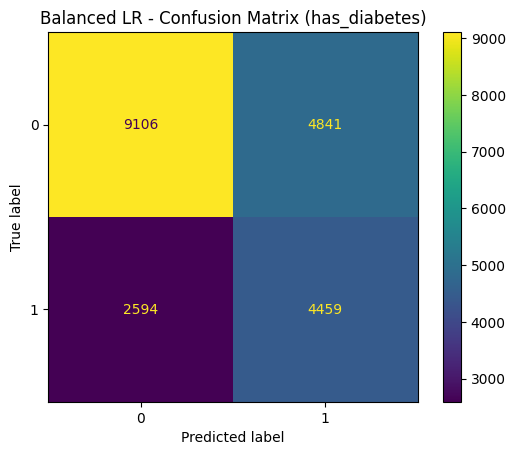

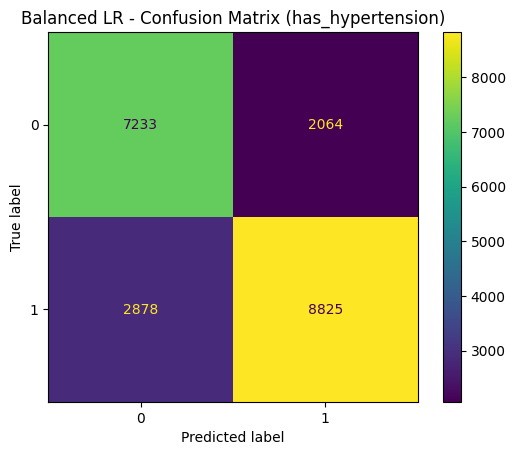

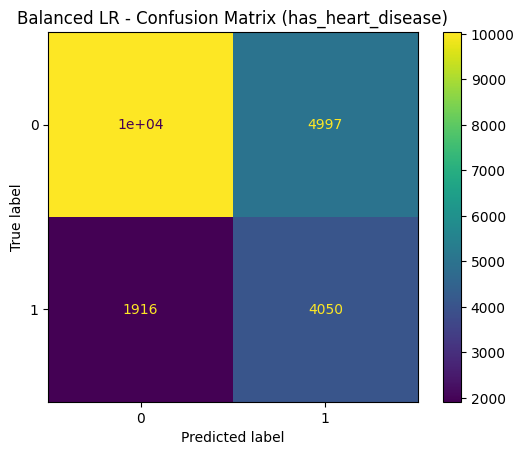

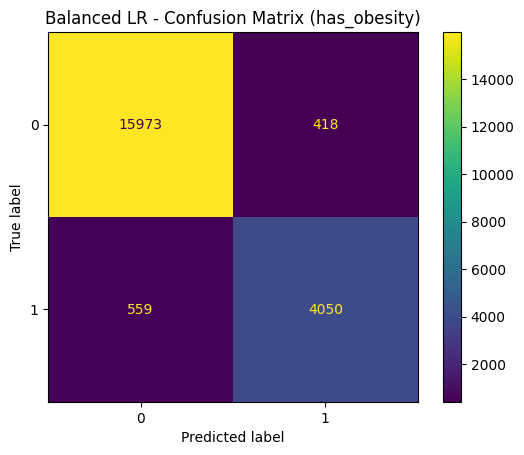

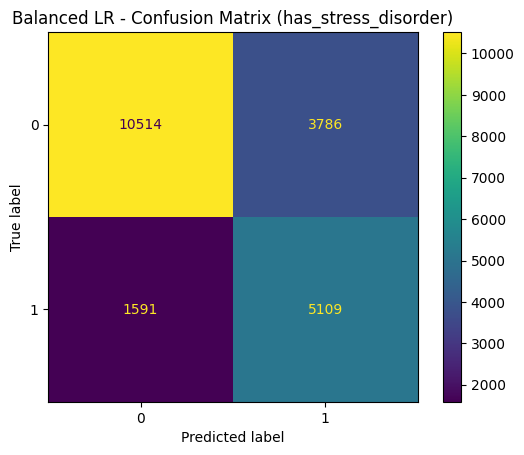

In [ ]:
# Plot confusion matrix for each target variable to evaluate classification performance
for i, col in enumerate(y.columns):
    cm = confusion_matrix(y_test.iloc[:, i], y_pred_best[:, i])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    plt.title(f"{best_model_name} - Confusion Matrix ({col})")
    plt.show()

In [ ]:
# Save trained model and scaler for future use
joblib.dump(best_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
# Compute ROC-AUC score for each target variable to evaluate classification performance
for i, col in enumerate(y.columns):
    y_prob = best_model.estimators_[i].predict_proba(X_test_scaled)[:, 1]

    auc = roc_auc_score(y_test.iloc[:, i], y_prob)

    print(f"{col} ROC-AUC: {auc:.3f}")

has_diabetes ROC-AUC: 0.701
has_hypertension ROC-AUC: 0.849
has_heart_disease ROC-AUC: 0.736
has_obesity ROC-AUC: 0.937
has_stress_disorder ROC-AUC: 0.820


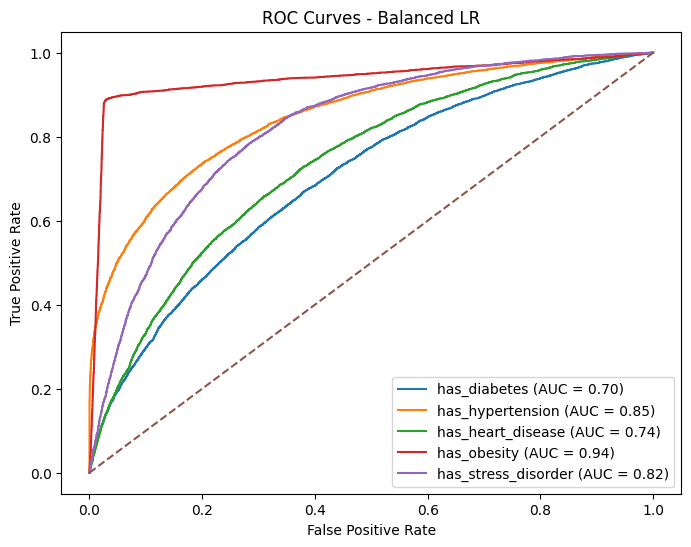

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Plot ROC curves for all target variables to assess model discrimination ability
plt.figure(figsize=(8,6))

for i, col in enumerate(y.columns):

    y_prob = best_model.estimators_[i].predict_proba(X_test_used)[:, 1]

    fpr, tpr, _ = roc_curve(y_test.iloc[:, i], y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{col} (AUC = {roc_auc:.2f})")

# Baseline diagonal line for random classifier comparison
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves - {best_model_name}")
plt.legend()
plt.show()

In [ ]:
!pip install shap


===== SHAP for has_diabetes =====


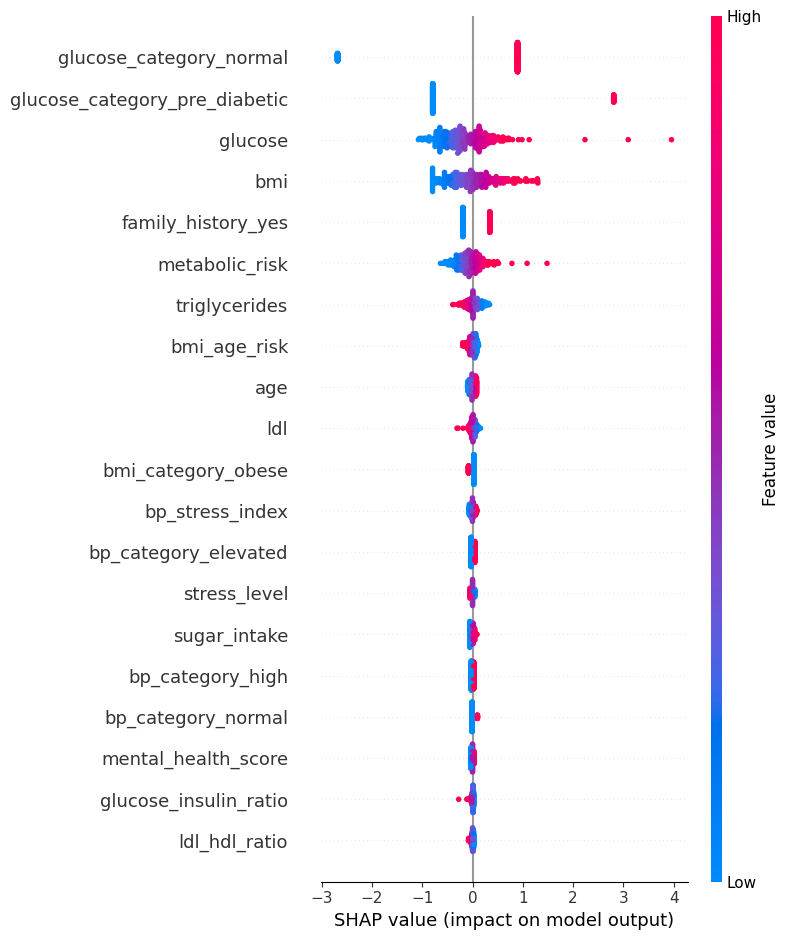


===== SHAP for has_hypertension =====


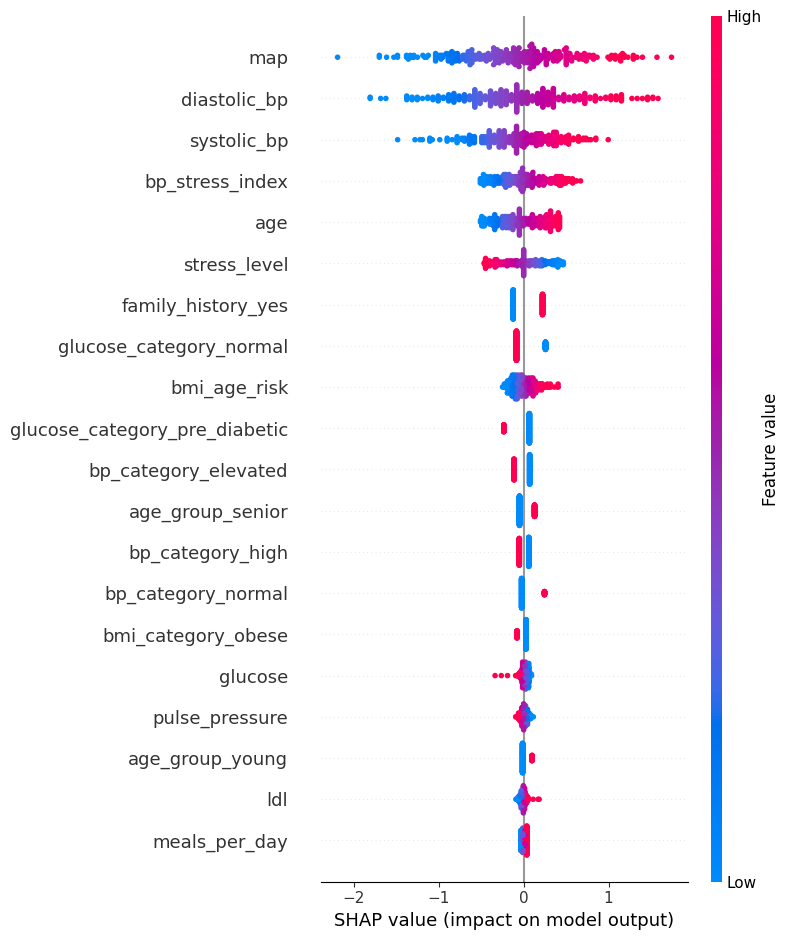


===== SHAP for has_heart_disease =====


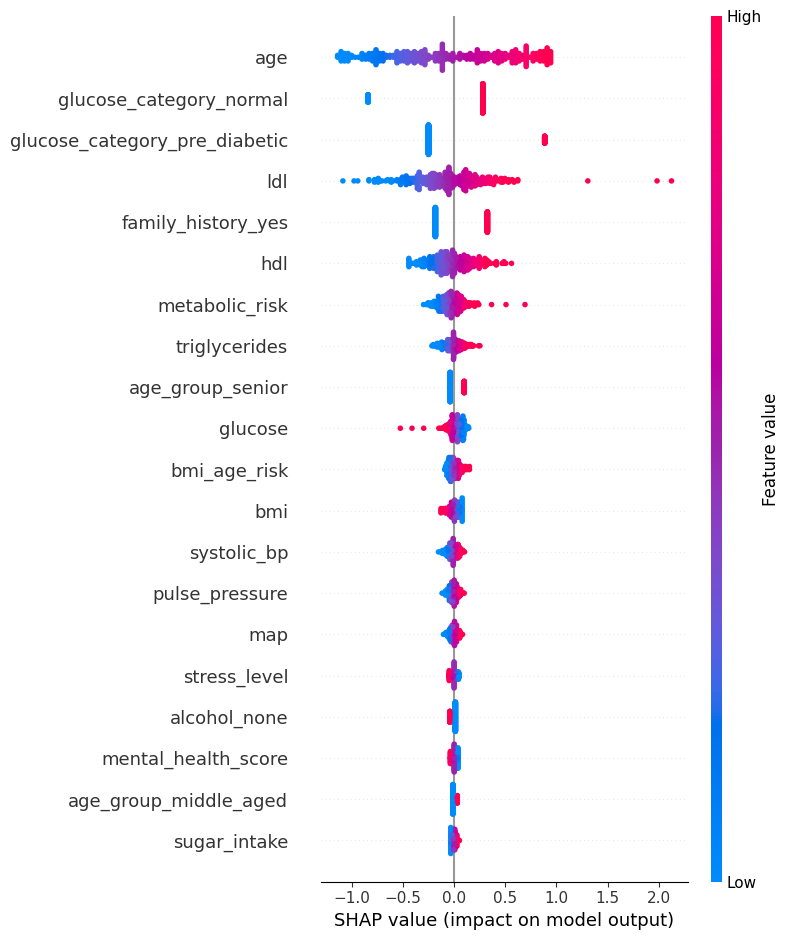


===== SHAP for has_obesity =====


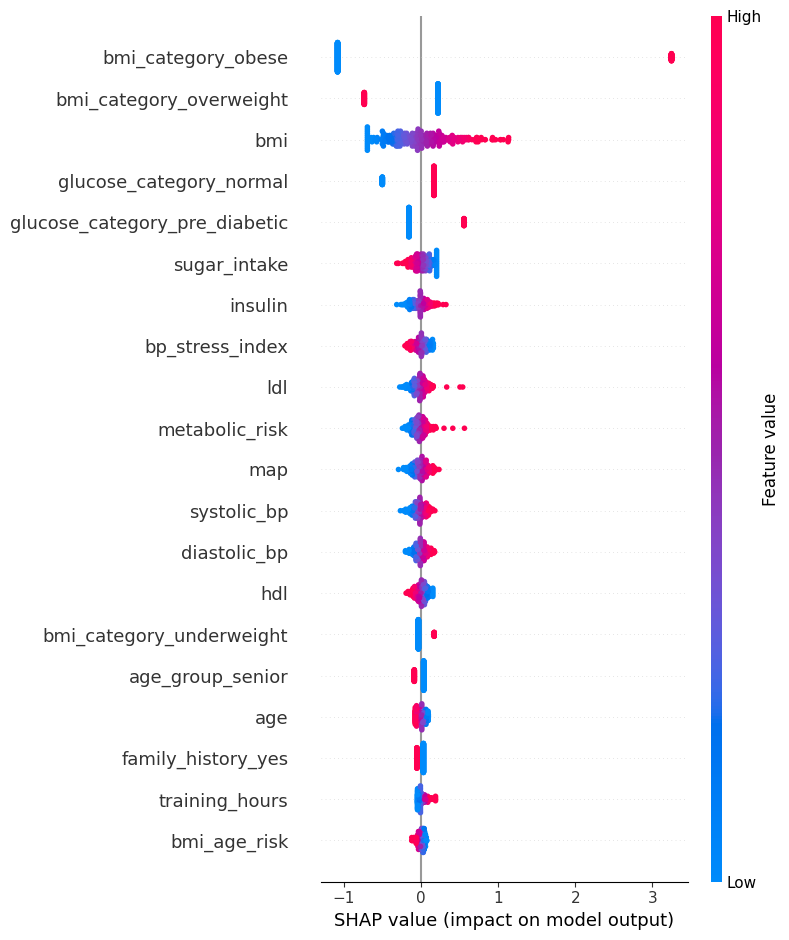


===== SHAP for has_stress_disorder =====


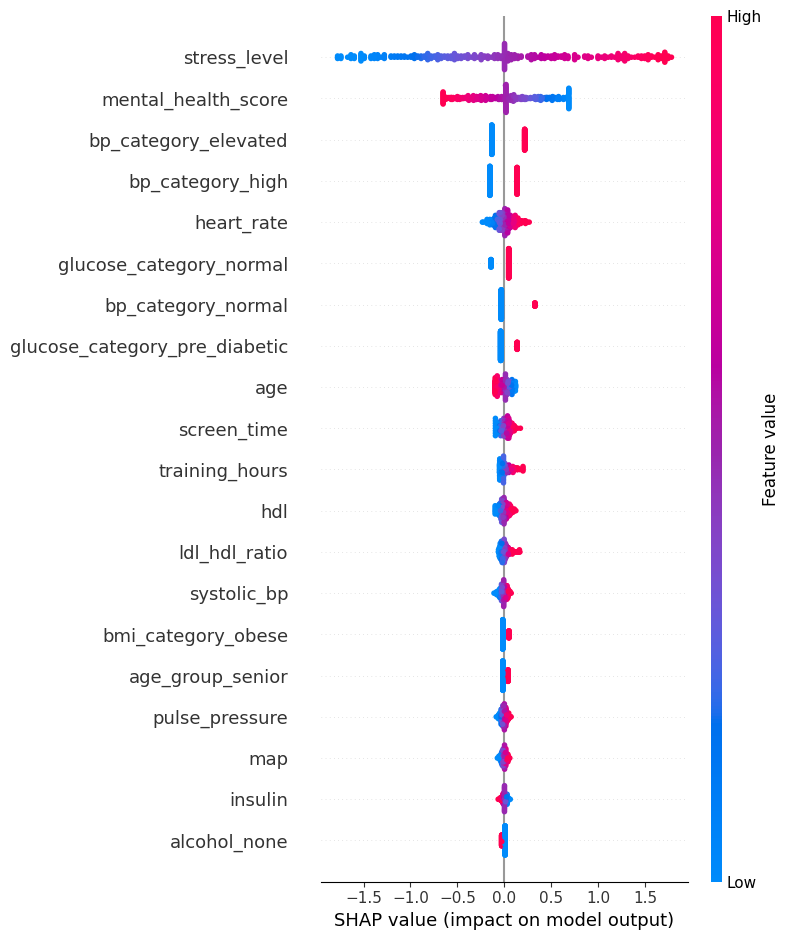

In [ ]:
shap.initjs()

# Generate SHAP explanations for each disease prediction model
for i, disease in enumerate(y.columns):

    print(f"\n===== SHAP for {disease} =====")

    est = best_model.estimators_[i]

    # Extract underlying model from calibrated classifier if needed
    if hasattr(est, "calibrated_classifiers_"):
        base_model = est.calibrated_classifiers_[0].estimator
    else:
        base_model = est
    # Create SHAP explainer for model interpretability
    explainer = shap.LinearExplainer(
        base_model,
        X_train_scaled
    )

    # Compute SHAP values for a sample of test data
    shap_values = explainer.shap_values(X_test_scaled[:300])
    # Visualise feature impact on predictions
    shap.summary_plot(
        shap_values,
        X_test_scaled[:300],
        feature_names=X_train.columns
    )

In [ ]:
# Perform feature engineering on a single input dataset by creating derived medical and risk-related features
def feature_engineering(df):
    df = df.copy()

    # Compute BMI if not already provided
    if "bmi" not in df.columns:
        df["bmi"] = df["weight"] / (df["height"] ** 2)

    # Combined metabolic risk score using key health indicators
    df["metabolic_risk"] = (
        df["bmi"] * 0.3 +
        df["glucose"] * 0.3 +
        df["ldl"] * 0.2 +
        df["triglycerides"] * 0.2
    )

    # Lipid ratio indicating cardiovascular risk
    df["ldl_hdl_ratio"] = df["ldl"] / (df["hdl"] + 1)

    # Pulse pressure
    df["pulse_pressure"] = df["systolic_bp"] - df["diastolic_bp"]

    # Mean arterial pressure (weighted blood pressure measure)
    df["map"] = (df["systolic_bp"] + 2 * df["diastolic_bp"]) / 3

    # Glucose-insulin interaction feature indicating insulin resistance
    df["glucose_insulin_ratio"] = df["glucose"] / (df["insulin"] + 1)

    # Age-adjusted BMI risk indicator
    df["bmi_age_risk"] = df["bmi"] * df["age"]

    # Stress-related cardiovascular load index
    df["bp_stress_index"] = df["stress_level"] * df["systolic_bp"]

    return df

In [ ]:
# Preprocess user input for model prediction by applying feature engineering, encoding, and scaling
def preprocess_user_input(user_input, scaler):

    # Load training feature structure to ensure alignment
    columns = joblib.load("columns.pkl")

    user_df = pd.DataFrame([user_input])

    # Standardise categorical text values
    for col in user_df.select_dtypes(include='object').columns:
        user_df[col] = user_df[col].str.lower()

    # Apply feature engineering to generate derived variables
    user_df = feature_engineering(user_df)

    # Convert categorical variables into numerical format using one-hot encoding
    user_df = pd.get_dummies(user_df)

    # Align input features with training columns
    user_df = user_df.reindex(columns=columns, fill_value=0)

    # Scale features using previously fitted scaler
    user_scaled = scaler.transform(user_df)

    return user_scaled

In [ ]:
# Generate rule-based explanations for predicted disease risk
def generate_reasons(disease, user_input):
    reasons = []

    # Compute BMI for reasoning logic
    bmi = user_input.get("weight", 0) / (user_input.get("height", 1) ** 2)

    # Diabetes-related risk factors
    if disease == "has_diabetes":
        if user_input.get("glucose", 0) > 125:
            reasons.append("Elevated blood glucose")
        if bmi > 27:
            reasons.append("High BMI")
        if user_input.get("family_history") == "yes":
            reasons.append("Family history of diabetes")
        if user_input.get("sugar_intake", 0) > 70:
            reasons.append("High sugar intake")
        if user_input.get("insulin", 0) > 20:
            reasons.append("High insulin level")

    # Hypertension risk factors
    elif disease == "has_hypertension":
        if user_input.get("systolic_bp", 0) > 130:
            reasons.append("High blood pressure")
        if user_input.get("stress_level", 0) > 6:
            reasons.append("High stress level")
        if user_input.get("age", 0) > 50:
            reasons.append("Age-related risk")
        if user_input.get("smoking") == "yes":
            reasons.append("Smoking habit")

    # Heart disease risk factors
    elif disease == "has_heart_disease":
        if user_input.get("ldl", 0) > 140:
            reasons.append("High LDL (bad cholesterol)")
        if user_input.get("hdl", 0) < 40:
            reasons.append("Low HDL (good cholesterol)")
        if user_input.get("systolic_bp", 0) > 140:
            reasons.append("High blood pressure")
        if user_input.get("smoking") == "yes":
            reasons.append("Smoking habit")

    # Obesity risk factors
    elif disease == "has_obesity":
        bmi = user_input.get("weight", 0) / (user_input.get("height", 1) ** 2)
        if bmi > 30:
            reasons.append("High BMI")
        if user_input.get("daily_steps", 0) < 5000:
            reasons.append("Low physical activity")
        if user_input.get("calorie_intake", 0) > 2500:
            reasons.append("High calorie intake")

    # Stress disorder risk factors
    elif disease == "has_stress_disorder":
        if user_input.get("stress_level", 0) > 7:
            reasons.append("High stress level")
        if user_input.get("mental_health_score", 10) < 5:
            reasons.append("Low mental health score")
        if user_input.get("screen_time", 0) > 6:
            reasons.append("High screen time")
        if user_input.get("sleep_hours", 10) < 6:
            reasons.append("Poor sleep")

    return reasons if reasons else ["All metrics within healthy range"]

In [ ]:
# Predict disease probabilities, apply rule-based adjustments, and generate risk interpretation
def predict_diseases(user_processed, best_model, y_columns, user_input):

    disease_pred = {}

    for i, col in enumerate(y_columns):

        est = best_model.estimators_[i]
        prob = est.predict_proba(user_processed)[0][1]


        # Rule-based adjustment for diabetes based on extreme glucose values
        if col == "has_diabetes" and user_input.get("glucose", 0) > 180:
              prob = max(prob, 0.75)

        if col == "has_diabetes":

            glucose = user_input.get("glucose", 0)
            insulin = user_input.get("insulin", 0)
            bmi = user_input.get("weight", 0) / (user_input.get("height", 1) ** 2)

            # Medical threshold adjustments
            if glucose >= 200:
                prob = max(prob, 0.85)

            elif glucose >= 140:
                prob = max(prob, 0.6)
            elif glucose >= 125:
                prob = max(prob, 0.5)

            if insulin >= 25:
                prob = max(prob, 0.6)

            if bmi >= 30:
                prob = max(prob, 0.55)


        # Rule-based adjustment for obesity
        bmi = user_input.get("weight", 0) / (user_input.get("height", 1) ** 2)

        if col == "has_obesity" and bmi >= 30:
            prob = max(prob, 0.7)


        # Ensure probability stays within valid range
        prob = float(prob)
        prob = max(0.01, min(prob, 0.99))


        # Decision thresholds per disease
        thresholds = {
            "has_diabetes": 0.45,
            "has_hypertension": 0.45,
            "has_heart_disease": 0.4,
            "has_obesity": 0.5,
            "has_stress_disorder": 0.45
        }

        threshold = thresholds[col]

        pred = int(prob >= threshold)


        # Convert prediction into risk level label
        if pred == 1:
            if prob >= 0.7:
                risk = "High Risk "
            else:
                risk = "Moderate Risk "
        else:
            risk = "Low Risk "

        # Store final prediction output with explanation
        disease_pred[col] = {
            "prediction": "Yes" if pred == 1 else "No",
            "probability": round(prob, 2),
            "risk_level": risk,
            "reasons": generate_reasons(col, user_input)
        }

    return disease_pred

In [ ]:
# Generate lifestyle and medical recommendations based on predicted disease risks
def generate_recommendations(disease_pred):
    recs = set()

    # Loop through each predicted disease and its results
    for disease, info in disease_pred.items():

        # Only generate recommendations for positive predictions
        if info["prediction"] == "Yes":

            if disease == "has_diabetes":
                recs.add("Reduce sugar intake and monitor glucose levels")

            if disease == "has_hypertension":
                recs.add("Reduce salt intake and monitor blood pressure")

            if disease == "has_heart_disease":
                recs.add("Adopt a heart-healthy diet and exercise regularly")

            if disease == "has_obesity":
                recs.add("Focus on weight management through diet and exercise")

            if disease == "has_stress_disorder":
                recs.add("Practice stress management techniques (meditation, sleep hygiene)")

    return list(recs)

In [ ]:
# Generate a final structured health report based on model predictions
def generate_report(disease_pred):

    # Handle missing predictions safely
    if disease_pred is None:
        print("Error: No predictions generated")
        return

    print("\n========== FINAL HEALTH REPORT ==========\n")

    all_reasons = set()

    high = 0
    moderate = 0

    # Count overall risk levels across all diseases
    for v in disease_pred.values():
        risk = str(v.get("risk_level", ""))

        if risk.startswith("High"):
            high += 1
        elif risk.startswith("Moderate"):
            moderate += 1

    # Determine overall patient status based on risk distribution
    if high >= 1:
        overall_status = " High Risk Patient"
    elif moderate >= 1:
        overall_status = " Moderate Risk Patient"
    else:
        overall_status = " Healthy"

    print(f"Overall Status: {overall_status}\n")

    # Display individual disease predictions and collect risk factors
    for disease, info in disease_pred.items():
        print(disease.replace("has_", "").title())
        print("Prediction:", info.get("prediction"))
        print("Probability:", info.get("probability"))
        print("Risk Level:", info.get("risk_level"))
        # print("Reasons:", ", ".join(info.get("reasons", [])))

        # Collect and clean contributing risk factors
        for r in info.get("reasons", []):
            if r not in ["No strong clinical indicators", "All metrics within healthy range"]:
                all_reasons.add(r.strip())

        # Helper function to clean reason text
        def clean_reason_text(text):
            text = text.replace("of diabetes", "")
            text = " ".join(text.split())
            return text.strip()
        print()


    # Display aggregated key risk factors
    if all_reasons:
        print("Key Risk Factors:\n")
        for r in all_reasons:
            print("-", clean_reason_text(r))
        print()
    print("Recommendations:\n")

    # If user is healthy, no further recommendations are needed
    if overall_status == " Healthy":
        print("- Maintain healthy lifestyle")
        return

    # Otherwise, generate targeted recommendations
    for rec in generate_recommendations(disease_pred):
        print("-", rec)

In [ ]:
# Example user input for prediction
user_input = {
    "age": 45,
    "gender": "male",
    "family_history": "yes",
    "weight": 80,
    "height": 1.75,
    "sleep_hours": 6,
    "daily_steps": 4000,
    "training_hours": 1,
    "screen_time": 7,
    "meals_per_day": 3,
    "calorie_intake": 2500,
    "sugar_intake": 80,
    "diet_type": "omnivore",
    "stress_level": 7,
    "mental_health_score": 5,
    "smoking": "yes",
    "alcohol": "moderate",
    "systolic_bp": 145,
    "diastolic_bp": 95,
    "ldl": 160,
    "hdl": 40,
    "triglycerides": 200,
    "total_cholesterol": 240,
    "glucose": 180,
    "insulin": 20,
    "heart_rate": 85
}

In [ ]:
# Load trained model and scaler from saved files
best_model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

# Preprocess input using same pipeline as training data
user_processed = preprocess_user_input(user_input, scaler)

# Generate disease predictions
disease_pred = predict_diseases(user_processed, best_model, y.columns, user_input)

# Display final report
generate_report(disease_pred)


========== FINAL HEALTH REPORT ==========

Overall Status:  High Risk Patient

Diabetes
Prediction: Yes
Probability: 0.6
Risk Level: Moderate Risk 

Hypertension
Prediction: Yes
Probability: 0.78
Risk Level: High Risk 

Heart_Disease
Prediction: No
Probability: 0.37
Risk Level: Low Risk 

Obesity
Prediction: No
Probability: 0.13
Risk Level: Low Risk 

Stress_Disorder
Prediction: Yes
Probability: 0.51
Risk Level: Moderate Risk 

Key Risk Factors:

- High blood pressure
- High sugar intake
- Family history
- High stress level
- Elevated blood glucose
- High LDL (bad cholesterol)
- High screen time
- Low physical activity
- Smoking habit

Recommendations:

- Reduce salt intake and monitor blood pressure
- Practice stress management techniques (meditation, sleep hygiene)
- Reduce sugar intake and monitor glucose levels


In [ ]:
print("Testing model with different patient profiles...")

Testing model with different patient profiles...


In [ ]:
# healthy user - expected -> healthy/low risk
user_input = {
    "age": 25,
    "gender": "female",
    "family_history": "no",
    "weight": 60,
    "height": 1.70,
    "sleep_hours": 8,
    "daily_steps": 10000,
    "training_hours": 3,
    "screen_time": 3,
    "meals_per_day": 3,
    "calorie_intake": 2000,
    "sugar_intake": 30,
    "diet_type": "vegetarian",
    "stress_level": 2,
    "mental_health_score": 8,
    "smoking": "no",
    "alcohol": "none",
    "systolic_bp": 110,
    "diastolic_bp": 70,
    "ldl": 90,
    "hdl": 60,
    "triglycerides": 100,
    "total_cholesterol": 170,
    "glucose": 90,
    "insulin": 8,
    "heart_rate": 65
}

In [ ]:
best_model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

user_processed = preprocess_user_input(user_input, scaler)

disease_pred = predict_diseases(user_processed, best_model, y.columns, user_input)

generate_report(disease_pred)


========== FINAL HEALTH REPORT ==========

Overall Status:  Healthy

Diabetes
Prediction: No
Probability: 0.01
Risk Level: Low Risk 

Hypertension
Prediction: No
Probability: 0.02
Risk Level: Low Risk 

Heart_Disease
Prediction: No
Probability: 0.03
Risk Level: Low Risk 

Obesity
Prediction: No
Probability: 0.03
Risk Level: Low Risk 

Stress_Disorder
Prediction: No
Probability: 0.07
Risk Level: Low Risk 

Recommendations:

- Maintain healthy lifestyle


In [ ]:
# high risk/ worse case
user_input = {
    "age": 60,
    "gender": "male",
    "family_history": "yes",
    "weight": 95,
    "height": 1.65,
    "sleep_hours": 5,
    "daily_steps": 2000,
    "training_hours": 0,
    "screen_time": 10,
    "meals_per_day": 5,
    "calorie_intake": 3200,
    "sugar_intake": 120,
    "diet_type": "omnivore",
    "stress_level": 9,
    "mental_health_score": 3,
    "smoking": "yes",
    "alcohol": "high",
    "systolic_bp": 170,
    "diastolic_bp": 110,
    "ldl": 200,
    "hdl": 30,
    "triglycerides": 300,
    "total_cholesterol": 300,
    "glucose": 220,
    "insulin": 30,
    "heart_rate": 100
}

In [ ]:
best_model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

user_processed = preprocess_user_input(user_input, scaler)

disease_pred = predict_diseases(user_processed, best_model, y.columns, user_input)

generate_report(disease_pred)


========== FINAL HEALTH REPORT ==========

Overall Status:  High Risk Patient

Diabetes
Prediction: Yes
Probability: 0.85
Risk Level: High Risk 

Hypertension
Prediction: Yes
Probability: 0.99
Risk Level: High Risk 

Heart_Disease
Prediction: Yes
Probability: 0.76
Risk Level: High Risk 

Obesity
Prediction: Yes
Probability: 0.7
Risk Level: High Risk 

Stress_Disorder
Prediction: Yes
Probability: 0.78
Risk Level: High Risk 

Key Risk Factors:

- High blood pressure
- High sugar intake
- High insulin level
- Family history
- Low HDL (good cholesterol)
- High calorie intake
- Poor sleep
- High stress level
- Elevated blood glucose
- High LDL (bad cholesterol)
- High screen time
- Low mental health score
- Low physical activity
- Smoking habit
- High BMI
- Age-related risk

Recommendations:

- Focus on weight management through diet and exercise
- Reduce salt intake and monitor blood pressure
- Practice stress management techniques (meditation, sleep hygiene)
- Adopt a heart-healthy diet 

In [ ]:
# borderline case
user_input = {
    "age": 45,
    "gender": "male",
    "family_history": "yes",
    "weight": 82,
    "height": 1.75,
    "sleep_hours": 6,
    "daily_steps": 5000,
    "training_hours": 1,
    "screen_time": 6,
    "meals_per_day": 3,
    "calorie_intake": 2500,
    "sugar_intake": 70,
    "diet_type": "omnivore",
    "stress_level": 6,
    "mental_health_score": 5,
    "smoking": "no",
    "alcohol": "moderate",
    "systolic_bp": 135,
    "diastolic_bp": 85,
    "ldl": 150,
    "hdl": 45,
    "triglycerides": 180,
    "total_cholesterol": 230,
    "glucose": 140,
    "insulin": 18,
    "heart_rate": 80
}

In [ ]:
best_model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

user_processed = preprocess_user_input(user_input, scaler)

disease_pred = predict_diseases(user_processed, best_model, y.columns, user_input)

generate_report(disease_pred)


========== FINAL HEALTH REPORT ==========

Overall Status:  Moderate Risk Patient

Diabetes
Prediction: Yes
Probability: 0.6
Risk Level: Moderate Risk 

Hypertension
Prediction: No
Probability: 0.45
Risk Level: Low Risk 

Heart_Disease
Prediction: No
Probability: 0.32
Risk Level: Low Risk 

Obesity
Prediction: No
Probability: 0.1
Risk Level: Low Risk 

Stress_Disorder
Prediction: No
Probability: 0.38
Risk Level: Low Risk 

Key Risk Factors:

- High LDL (bad cholesterol)
- High blood pressure
- Family history
- Elevated blood glucose

Recommendations:

- Reduce sugar intake and monitor glucose levels
